# 디렉토리 구조

    /kaggle/input/competitions/ai09-level1-project/
    └── sprint_ai_project1_data/
        ├── train_images/
        │   ├── K-001900-016548-019607-029451_0_2_0_2_70_000_200.png
        │   ├── ...
        │
        ├── train_annotations/
        │   ├── K-001900-016548-019607-029451_json/
        │   │   └── K-001900/
        │   │       └── K-001900-016548-019607-029451_0_2_0_2_70_000_200.json
        │   ├── ...
        │
        └── test_images/
            ├── 1.png
            ├── 2.png
            ├── ...

# 0. Import / Path Setting

In [1]:
# =========================================
# 0. Import / Environment Setup
# =========================================

# 기본 라이브러리
import os
import json
from pathlib import Path
from collections import Counter
import random

# 데이터 처리
import numpy as np
import pandas as pd

# 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns

# 이미지 처리
import cv2

# =========================================
#  Seaborn 기본 설정
# =========================================
sns.set_style("whitegrid")
sns.set_context("notebook")
plt.rcParams["axes.unicode_minus"] = False

# -----------------------------------------
# Matplotlib 기본 설정
# -----------------------------------------
mpl.rcdefaults()  # 기존 설정 초기화
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.unicode_minus"] = False

# -----------------------------------------
# 한글 폰트 설정 (경로 기반)
# -----------------------------------------
!apt-get update -qq
!apt-get install -y fonts-nanum -qq

# 1) 기존 rcParams 초기화
mpl.rcdefaults()

# 2) 사용할 폰트 파일 경로 후보
candidate_paths = [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
    "/usr/share/fonts/truetype/nanum/NanumSquareR.ttf",
]

font_path = None
for p in candidate_paths:
    if os.path.exists(p):
        font_path = p
        break

if font_path is None:
    raise FileNotFoundError("사용 가능한 한글 폰트를 찾지 못했습니다.")

# 3) 폰트 등록
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

# 4) 전역 적용
mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

print("사용 폰트 파일:", font_path)
print("등록된 폰트 이름:", font_name)

# =========================================
# Path Setting (Kaggle 기준)
# =========================================

BASE_DIR = Path("/kaggle/input/competitions/ai09-level1-project/sprint_ai_project1_data")

TRAIN_IMG_DIR = BASE_DIR / "train_images"
TRAIN_ANN_DIR = BASE_DIR / "train_annotations"
TEST_IMG_DIR = BASE_DIR / "test_images"

# -----------------------------------------
# 파일 리스트 생성
# -----------------------------------------
train_img_paths = sorted(TRAIN_IMG_DIR.glob("*.png"))
test_img_paths = sorted(TEST_IMG_DIR.glob("*.png"))

# 🔥 핵심 (JSON은 하위 폴더까지 포함)
train_json_paths = sorted(TRAIN_ANN_DIR.rglob("*.json"))

# -----------------------------------------
# 확인
# -----------------------------------------
print("train image files:", len(train_img_paths))
print("train json files :", len(train_json_paths))
print("test image files :", len(test_img_paths))

print("\n[example paths]")
print("train image:", train_img_paths[0] if train_img_paths else None)
print("train json :", train_json_paths[0] if train_json_paths else None)
print("test image :", test_img_paths[0] if test_img_paths else None)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 120314 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
사용 폰트 파일: /usr/share/fonts/truetype/nanum/NanumGothic.ttf
등록된 폰트 이름: NanumGothic
train image files: 232
train json files : 763
test image files : 842

[example paths]
train image: /kaggle/input/competitions/ai09-level1-project/sprint_ai_project1_data/train_images/K-001900-016548-019607-029451_0_2_0_2_70_000_200.png
train json : /kaggle/input/competitions/ai09-level1-project/sprint_ai_project1_data/train_annotations/K-001900-016548-019607-029451_json/K-001900/K-001900-016548-019607-02

---

# 1. Train 이미지 EDA

## 1-1. JSON 로드 + 통합

In [2]:
# =========================================
# 1-1. Train JSON Load (수정본)
# JSON 1개 = 객체 1개 후보로 직접 파싱
# =========================================
all_image_rows = []
all_ann_rows = []
all_cat_rows = []
json_rows = []
obj_rows = []

for jp in train_json_paths:
    with open(jp, "r", encoding="utf-8") as f:
        data = json.load(f)

    leaf_dir = jp.parent.name          # 예: K-001900
    upper_dir = jp.parent.parent.name  # 예: K-001900-016548-019607-029451_json

    images = data.get("images", [])
    anns = data.get("annotations", [])
    cats = data.get("categories", [])

    # 원본 확인용 raw row 누적
    for x in images:
        row = dict(x)
        row["json_path"] = str(jp)
        row["leaf_dir"] = leaf_dir
        row["upper_dir"] = upper_dir
        all_image_rows.append(row)

    for x in anns:
        row = dict(x)
        row["json_path"] = str(jp)
        row["leaf_dir"] = leaf_dir
        row["upper_dir"] = upper_dir
        all_ann_rows.append(row)

    for x in cats:
        row = dict(x)
        row["json_path"] = str(jp)
        row["leaf_dir"] = leaf_dir
        row["upper_dir"] = upper_dir
        all_cat_rows.append(row)

    # JSON 단위 요약 row
    img0 = images[0] if len(images) > 0 else {}
    cat0 = cats[0] if len(cats) > 0 else {}

    json_rows.append({
        "json_path": str(jp),
        "upper_dir": upper_dir,
        "leaf_dir": leaf_dir,
        "file_name": img0.get("file_name"),
        "image_id": img0.get("id"),
        "num_images": len(images),
        "num_annotations": len(anns),
        "num_categories": len(cats),
        "cat_id_from_category": cat0.get("id"),
        "cat_name_from_category": cat0.get("name"),
    })

    # -----------------------------------------
    # object-level row 생성
    # -----------------------------------------
    for ann in anns:
        bbox = ann.get("bbox", None)

        # 존재 + 유효 bbox만 사용
        if not (isinstance(bbox, list) and len(bbox) == 4):
            continue

        x, y, w, h = bbox

        obj_rows.append({
            # 경로 정보
            "json_path": str(jp),
            "upper_dir": upper_dir,
            "leaf_dir": leaf_dir,

            # image info
            "file_name": img0.get("file_name"),
            "image_id": img0.get("id"),
            "img_width": img0.get("width"),
            "img_height": img0.get("height"),

            # annotation info
            "annotation_id": ann.get("id"),
            "category_id": ann.get("category_id"),
            "bbox": bbox,
            "x": x,
            "y": y,
            "w": w,
            "h": h,
            "area": ann.get("area", w * h),

            # image-level metadata from this JSON
            "dl_idx": img0.get("dl_idx"),
            "dl_name": img0.get("dl_name"),
            "color_class1": img0.get("color_class1"),
            "color_class2": img0.get("color_class2"),
            "drug_shape": img0.get("drug_shape"),
            "form_code_name": img0.get("form_code_name"),
            "print_front": img0.get("print_front"),
            "print_back": img0.get("print_back"),
            "thick": img0.get("thick"),
            "leng_long": img0.get("leng_long"),
            "leng_short": img0.get("leng_short"),
        })

# DataFrame 생성
img_df = pd.DataFrame(all_image_rows)
ann_df = pd.DataFrame(all_ann_rows)
cat_df = pd.DataFrame(all_cat_rows)
json_df = pd.DataFrame(json_rows)
obj_df = pd.DataFrame(obj_rows)

print("raw image records     :", len(img_df))
print("raw annotation records:", len(ann_df))
print("raw category records  :", len(cat_df))
print("json rows             :", len(json_df))
print("object rows (valid)   :", len(obj_df))

display(json_df.head())
display(obj_df.head())

raw image records     : 763
raw annotation records: 763
raw category records  : 763
json rows             : 763
object rows (valid)   : 763


,json_path,upper_dir,leaf_dir,file_name,image_id,num_images,num_annotations,num_categories,cat_id_from_category,cat_name_from_category
0,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-001900,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,34,1,1,1,1900,보령부스파정 5mg
1,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-001900,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,35,1,1,1,1900,보령부스파정 5mg
2,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-001900,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,36,1,1,1,1900,보령부스파정 5mg
3,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-016548,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,34,1,1,1,16548,가바토파정 100mg
4,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-016548,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,35,1,1,1,16548,가바토파정 100mg


,json_path,upper_dir,leaf_dir,file_name,image_id,img_width,img_height,annotation_id,category_id,bbox,...,dl_name,color_class1,color_class2,drug_shape,form_code_name,print_front,print_back,thick,leng_long,leng_short
0,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-001900,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,34,976,1280,133,1900,"[644, 845, 189, 190]",...,보령부스파정 5mg,하양,,장방형,나정,BSP,5,2.5,8.0,4.5
1,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-001900,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,35,976,1280,134,1900,"[148, 241, 181, 181]",...,보령부스파정 5mg,하양,,장방형,나정,BSP,5,2.5,8.0,4.5
2,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-001900,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,36,976,1280,135,1900,"[167, 248, 184, 182]",...,보령부스파정 5mg,하양,,장방형,나정,BSP,5,2.5,8.0,4.5
3,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-016548,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,34,976,1280,136,16548,"[144, 799, 239, 239]",...,가바토파정 100mg,None,None,None,None,None,None,0.0,0.0,0.0
4,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-016548,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,35,976,1280,137,16548,"[578, 222, 233, 226]",...,가바토파정 100mg,None,None,None,None,None,None,0.0,0.0,0.0


## 1-2. 실제 이미지 vs JSON image

In [3]:
# =========================================
# 1-2. Image Count Analysis (수정본)
# =========================================
print("실제 이미지 파일 수:", len(train_img_paths))
print("JSON row 수       :", len(json_df))
print("고유 이미지 수     :", json_df["file_name"].nunique())
print("유효 객체 수       :", len(obj_df))

# 같은 file_name이 몇 개 leaf_dir에 걸쳐 있는지 확인
dup_by_leaf = (
    json_df.groupby("file_name")["leaf_dir"]
    .nunique()
    .reset_index(name="num_leaf_dirs")
    .sort_values("num_leaf_dirs", ascending=False)
)

print("\n[file_name별 leaf_dir 개수 상위]")
display(dup_by_leaf.head(20))

# 예시: 같은 이미지가 여러 leaf_dir에 존재하는지
multi_leaf_examples = dup_by_leaf[dup_by_leaf["num_leaf_dirs"] >= 2]["file_name"].head(5).tolist()

if len(multi_leaf_examples) > 0:
    print("\n[같은 file_name이 여러 leaf_dir에 존재하는 예시]")
    display(
        json_df[json_df["file_name"].isin(multi_leaf_examples)]
        .sort_values(["file_name", "leaf_dir"])
        [["file_name", "leaf_dir", "upper_dir", "json_path"]]
        .reset_index(drop=True)
    )

실제 이미지 파일 수: 232
JSON row 수       : 763
고유 이미지 수     : 232
유효 객체 수       : 763

[file_name별 leaf_dir 개수 상위]


,file_name,num_leaf_dirs
0,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,4
1,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,4
2,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,4
3,K-001900-016548-019607-033009_0_2_0_2_70_000_2...,4
4,K-001900-016548-019607-033009_0_2_0_2_75_000_2...,4
5,K-001900-016548-019607-033009_0_2_0_2_90_000_2...,4
6,K-001900-016548-021771-027926_0_2_0_2_70_000_2...,4
7,K-001900-016548-021771-027926_0_2_0_2_75_000_2...,4
8,K-001900-016548-021771-027926_0_2_0_2_90_000_2...,4
9,K-001900-016548-024850-029345_0_2_0_2_70_000_2...,4



[같은 file_name이 여러 leaf_dir에 존재하는 예시]


,file_name,leaf_dir,upper_dir,json_path
0,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,K-001900,K-001900-016548-019607-029451_json,/kaggle/input/competitions/ai09-level1-project...
1,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,K-016548,K-001900-016548-019607-029451_json,/kaggle/input/competitions/ai09-level1-project...
2,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,K-019607,K-001900-016548-019607-029451_json,/kaggle/input/competitions/ai09-level1-project...
3,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,K-029451,K-001900-016548-019607-029451_json,/kaggle/input/competitions/ai09-level1-project...
4,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,K-001900,K-001900-016548-019607-029451_json,/kaggle/input/competitions/ai09-level1-project...
5,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,K-016548,K-001900-016548-019607-029451_json,/kaggle/input/competitions/ai09-level1-project...
6,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,K-019607,K-001900-016548-019607-029451_json,/kaggle/input/competitions/ai09-level1-project...
7,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,K-029451,K-001900-016548-019607-029451_json,/kaggle/input/competitions/ai09-level1-project...
8,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,K-001900,K-001900-016548-019607-029451_json,/kaggle/input/competitions/ai09-level1-project...
9,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,K-016548,K-001900-016548-019607-029451_json,/kaggle/input/competitions/ai09-level1-project...


## 1-3. 이미지 크기 분포

In [4]:
# =========================================
# 1-3. 실제 이미지 크기 분포
# =========================================
img_sizes = []

for p in train_img_paths[:500]:
    img = cv2.imread(str(p))
    if img is not None:
        h, w = img.shape[:2]
        img_sizes.append((w, h))

size_df = pd.DataFrame(img_sizes, columns=["width", "height"])

display(size_df.describe())

,width,height
count,232.0,232.0
mean,976.0,1280.0
std,0.0,0.0
min,976.0,1280.0
25%,976.0,1280.0
50%,976.0,1280.0
75%,976.0,1280.0
max,976.0,1280.0


## 1-4. 이미지당 객체 수

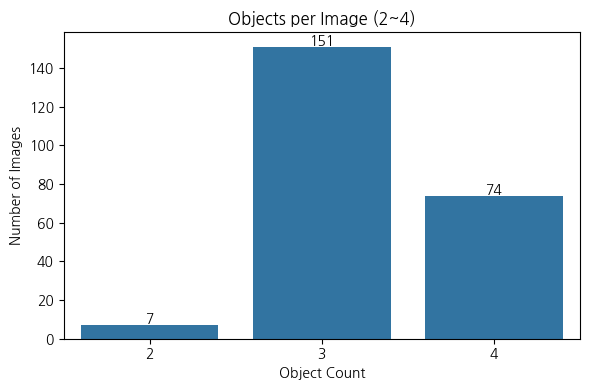

In [5]:
# =========================================
# 1-4. Objects per Image (Discrete Bar)
# =========================================
ann_df["valid_bbox"] = ann_df["bbox"].apply(lambda x: isinstance(x, list) and len(x) == 4)
valid_ann_df = ann_df[ann_df["valid_bbox"]]

obj_per_img = valid_ann_df.groupby("image_id").size()

# 원하는 값만 필터링 (2, 3, 4)
obj_filtered = obj_per_img[obj_per_img.isin([2, 3, 4])]

# 개수 집계
vc = obj_filtered.value_counts().sort_index()

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=vc.index, y=vc.values)

ax.set_title("Objects per Image (2~4)")
ax.set_xlabel("Object Count")
ax.set_ylabel("Number of Images")

# 값 라벨 표시
for i, v in enumerate(vc.values):
    ax.text(i, v + 1, str(v), ha="center")

plt.tight_layout()
plt.show()

---

# 2. Metadata EDA

## 2-0. JSON → DataFrame 생성

In [6]:
# =========================================
# 2-0. JSON / Object DataFrame 확인 (수정본)
# =========================================
print("json_df rows :", len(json_df))
print("obj_df rows  :", len(obj_df))
print("unique images:", obj_df["file_name"].nunique())

print("\n[obj_df 주요 컬럼]")
display(obj_df.head())

json_df rows : 763
obj_df rows  : 763
unique images: 232

[obj_df 주요 컬럼]


,json_path,upper_dir,leaf_dir,file_name,image_id,img_width,img_height,annotation_id,category_id,bbox,...,dl_name,color_class1,color_class2,drug_shape,form_code_name,print_front,print_back,thick,leng_long,leng_short
0,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-001900,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,34,976,1280,133,1900,"[644, 845, 189, 190]",...,보령부스파정 5mg,하양,,장방형,나정,BSP,5,2.5,8.0,4.5
1,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-001900,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,35,976,1280,134,1900,"[148, 241, 181, 181]",...,보령부스파정 5mg,하양,,장방형,나정,BSP,5,2.5,8.0,4.5
2,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-001900,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,36,976,1280,135,1900,"[167, 248, 184, 182]",...,보령부스파정 5mg,하양,,장방형,나정,BSP,5,2.5,8.0,4.5
3,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-016548,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,34,976,1280,136,16548,"[144, 799, 239, 239]",...,가바토파정 100mg,None,None,None,None,None,None,0.0,0.0,0.0
4,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-016548,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,35,976,1280,137,16548,"[578, 222, 233, 226]",...,가바토파정 100mg,None,None,None,None,None,None,0.0,0.0,0.0


## 2-1. 전체 컬럼 요약표

In [7]:
# =========================================
# 2-1. Metadata Overview (object-level) - 수정본
# list/dict 타입 안전 처리
# =========================================
meta_summary = []

for col in obj_df.columns:
    s = obj_df[col]

    # -----------------------------------------
    # hash 불가능한 타입(list, dict 등) 대비
    # -----------------------------------------
    def to_hashable(v):
        if isinstance(v, list):
            return str(v)
        if isinstance(v, dict):
            return str(v)
        return v

    s_safe = s.map(to_hashable)

    meta_summary.append({
        "column": col,
        "dtype": str(s.dtype),
        "missing": s.isna().sum(),
        "nunique": s_safe.nunique(dropna=True),
        "sample": str(s_safe.dropna().unique()[:3])
    })

meta_df = pd.DataFrame(meta_summary)
display(meta_df.sort_values("nunique", ascending=False).reset_index(drop=True))

,column,dtype,missing,nunique,sample
0,json_path,object,0,763,['/kaggle/input/competitions/ai09-level1-proje...
1,annotation_id,int64,0,763,[133 134 135]
2,bbox,object,0,759,"['[644, 845, 189, 190]' '[148, 241, 181, 181]'..."
3,area,int64,0,635,[35910 32761 33488]
4,y,int64,0,398,[845 241 248]
5,x,int64,0,380,[644 148 167]
6,h,int64,0,265,[190 181 182]
7,w,int64,0,239,[189 181 184]
8,image_id,int64,0,232,[34 35 36]
9,file_name,object,0,232,['K-001900-016548-019607-029451_0_2_0_2_70_000...


## 2-2. 주요 컬럼 필터링

In [8]:
# =========================================
# 2-2. Core Columns (수정본)
# obj_df를 직접 사용
# =========================================
core_cols = [
    "json_path",
    "upper_dir",
    "leaf_dir",
    "file_name",
    "image_id",
    "annotation_id",
    "category_id",
    "bbox",
    "x", "y", "w", "h", "area",
    "dl_idx",
    "dl_name",
    "color_class1",
    "color_class2",
    "drug_shape",
    "form_code_name",
    "print_front",
    "print_back",
    "thick",
    "leng_long",
    "leng_short",
]

core_cols = [c for c in core_cols if c in obj_df.columns]
obj_core_df = obj_df[core_cols].copy()

print("obj_core_df shape:", obj_core_df.shape)
display(obj_core_df.head())

obj_core_df shape: (763, 24)


,json_path,upper_dir,leaf_dir,file_name,image_id,annotation_id,category_id,bbox,x,y,...,dl_name,color_class1,color_class2,drug_shape,form_code_name,print_front,print_back,thick,leng_long,leng_short
0,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-001900,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,34,133,1900,"[644, 845, 189, 190]",644,845,...,보령부스파정 5mg,하양,,장방형,나정,BSP,5,2.5,8.0,4.5
1,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-001900,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,35,134,1900,"[148, 241, 181, 181]",148,241,...,보령부스파정 5mg,하양,,장방형,나정,BSP,5,2.5,8.0,4.5
2,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-001900,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,36,135,1900,"[167, 248, 184, 182]",167,248,...,보령부스파정 5mg,하양,,장방형,나정,BSP,5,2.5,8.0,4.5
3,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-016548,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,34,136,16548,"[144, 799, 239, 239]",144,799,...,가바토파정 100mg,None,None,None,None,None,None,0.0,0.0,0.0
4,/kaggle/input/competitions/ai09-level1-project...,K-001900-016548-019607-029451_json,K-016548,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,35,137,16548,"[578, 222, 233, 226]",578,222,...,가바토파정 100mg,None,None,None,None,None,None,0.0,0.0,0.0


## 2-3. annotation bbox 파싱

In [9]:
# =========================================
# 2-3. Check BBox Validity (수정본)
# =========================================
obj_df = obj_df.copy()
obj_df["valid_bbox"] = obj_df["bbox"].apply(lambda x: isinstance(x, list) and len(x) == 4)

print("valid bbox count:", obj_df["valid_bbox"].sum())
print("invalid bbox count:", (~obj_df["valid_bbox"]).sum())

display(
    obj_df[
        ["file_name", "category_id", "bbox", "x", "y", "w", "h", "area", "leaf_dir", "upper_dir"]
    ].head()
)

valid bbox count: 763
invalid bbox count: 0


,file_name,category_id,bbox,x,y,w,h,area,leaf_dir,upper_dir
0,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,1900,"[644, 845, 189, 190]",644,845,189,190,35910,K-001900,K-001900-016548-019607-029451_json
1,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,1900,"[148, 241, 181, 181]",148,241,181,181,32761,K-001900,K-001900-016548-019607-029451_json
2,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,1900,"[167, 248, 184, 182]",167,248,184,182,33488,K-001900,K-001900-016548-019607-029451_json
3,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,16548,"[144, 799, 239, 239]",144,799,239,239,57121,K-016548,K-001900-016548-019607-029451_json
4,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,16548,"[578, 222, 233, 226]",578,222,233,226,52658,K-016548,K-001900-016548-019607-029451_json


## 2-4. 클래스 분포

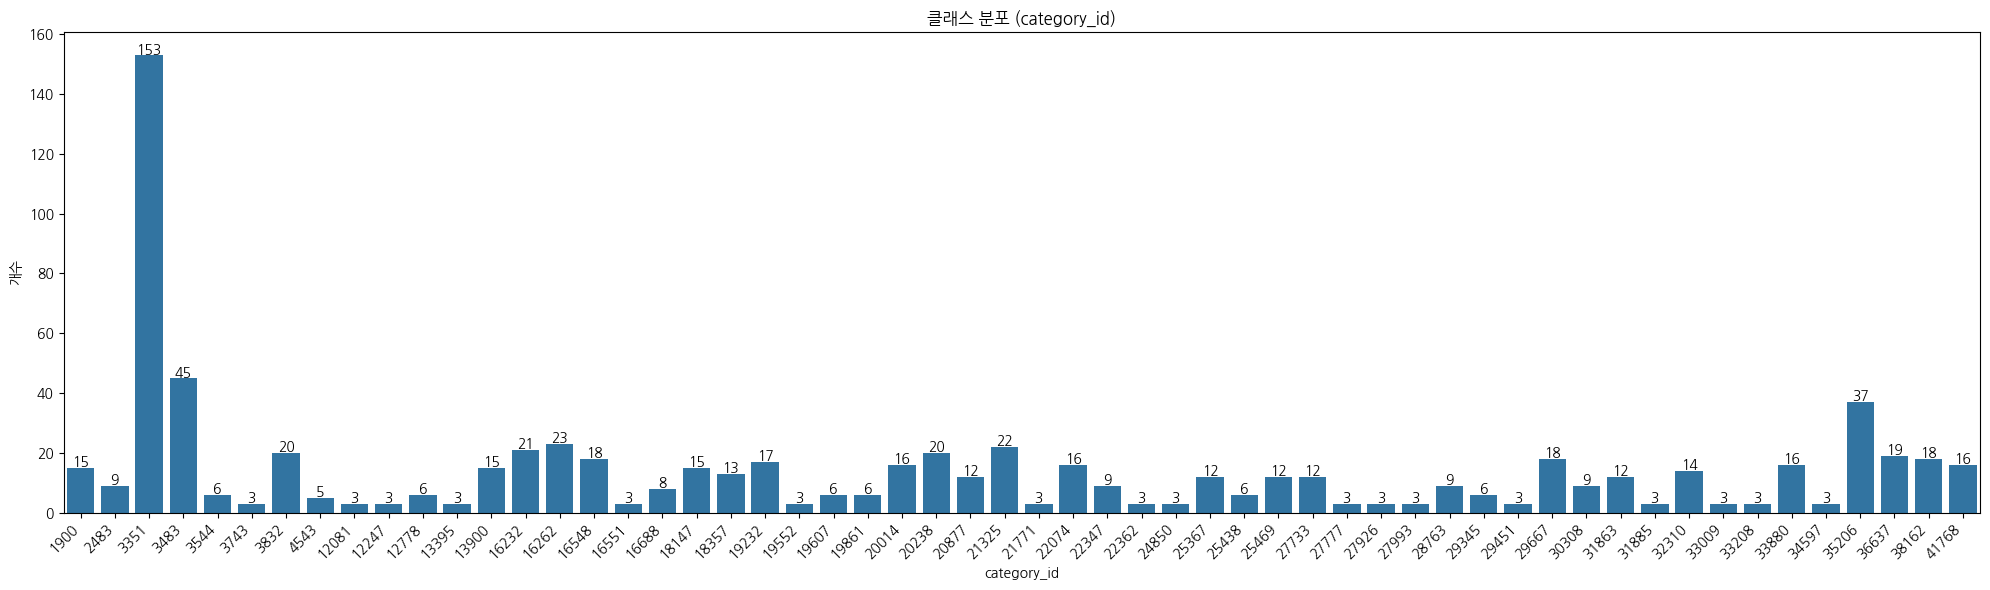

총 객체 수: 763


In [10]:
# =========================================
# 2-4. Class Distribution (category_id 기준)
# =========================================
class_counts = (
    obj_df["category_id"]
    .value_counts()
    .sort_index()
    .reset_index()
)
class_counts.columns = ["category_id", "count"]

plt.figure(figsize=(20, 6))
ax = sns.barplot(data=class_counts, x="category_id", y="count")

ax.set_title("클래스 분포 (category_id)")
ax.set_xlabel("category_id")
ax.set_ylabel("개수")

plt.xticks(rotation=45, ha="right")

for i, v in enumerate(class_counts["count"]):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print("총 객체 수:", class_counts["count"].sum())

## 2-5. 핵심 범주형 컬럼 분포

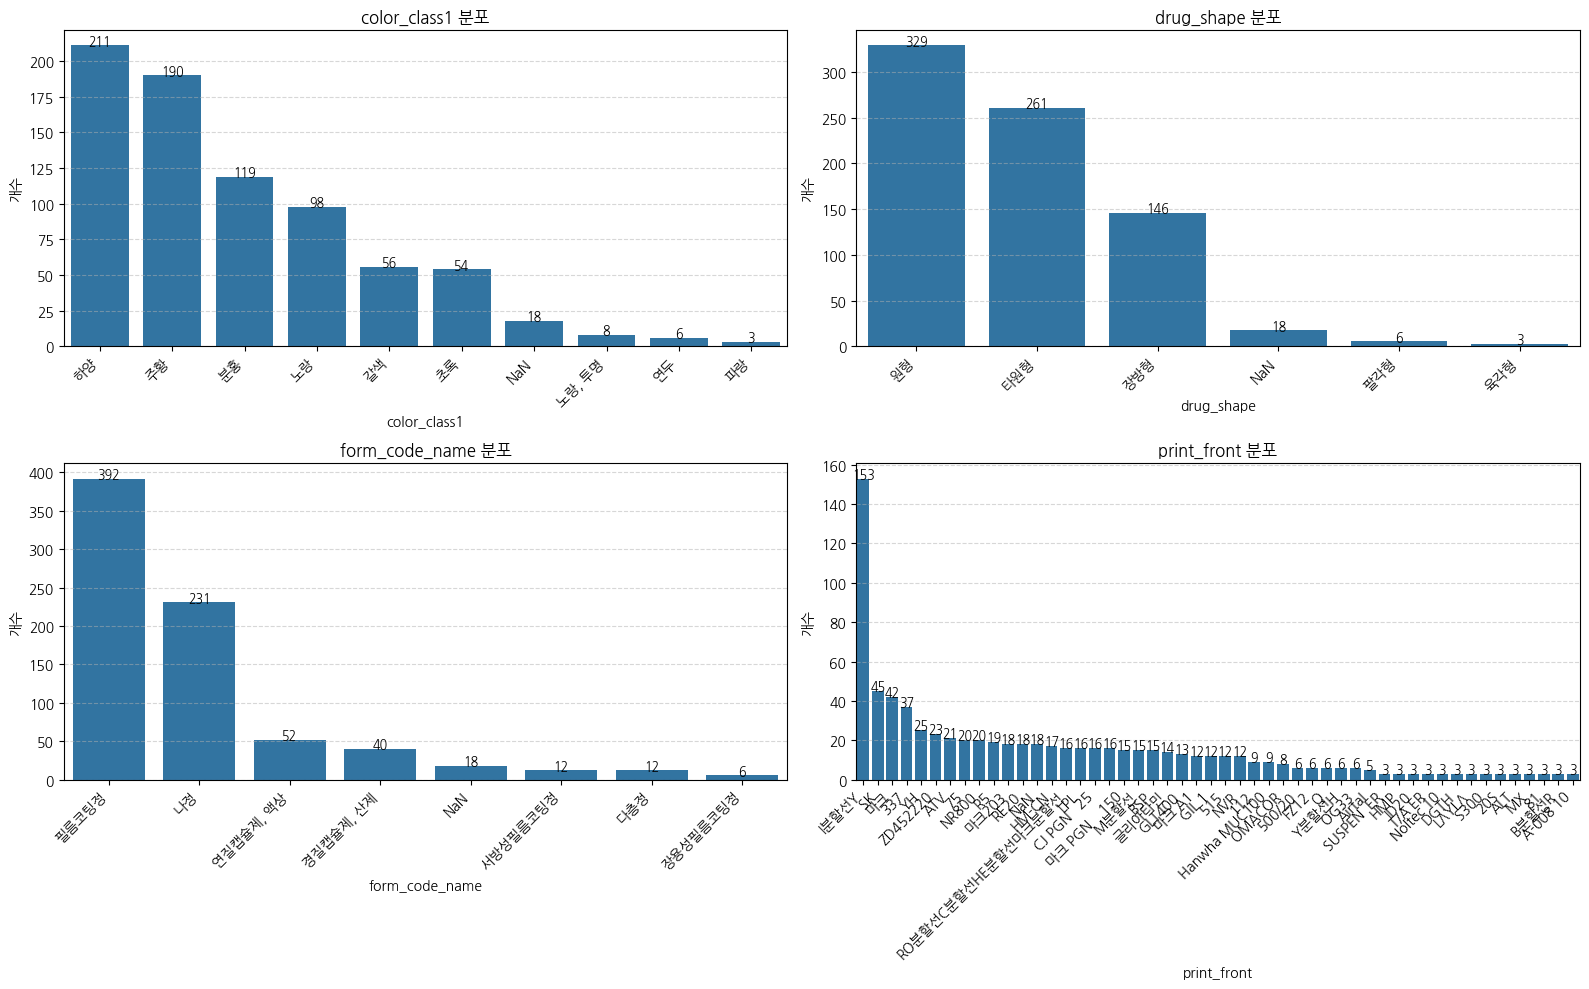

In [11]:
# =========================================
# 2-5. Key Metadata Distribution (object-level, 2x2) + Labels
# =========================================
plot_cols = ["color_class1", "drug_shape", "form_code_name", "print_front"]
plot_cols = [c for c in plot_cols if c in obj_df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    vc = obj_df[col].fillna("NaN").value_counts().reset_index()
    vc.columns = [col, "count"]

    ax = axes[i]
    sns.barplot(data=vc, x=col, y="count", ax=ax)

    ax.set_title(f"{col} 분포")
    ax.set_xlabel(col)
    ax.set_ylabel("개수")

    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

    for j, v in enumerate(vc["count"]):
        ax.text(j, v + 0.5, str(v), ha="center", fontsize=9)

    ax.grid(axis="y", linestyle="--", alpha=0.5)

for j in range(len(plot_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 2-6. 클래스 vs 색상 heatmap

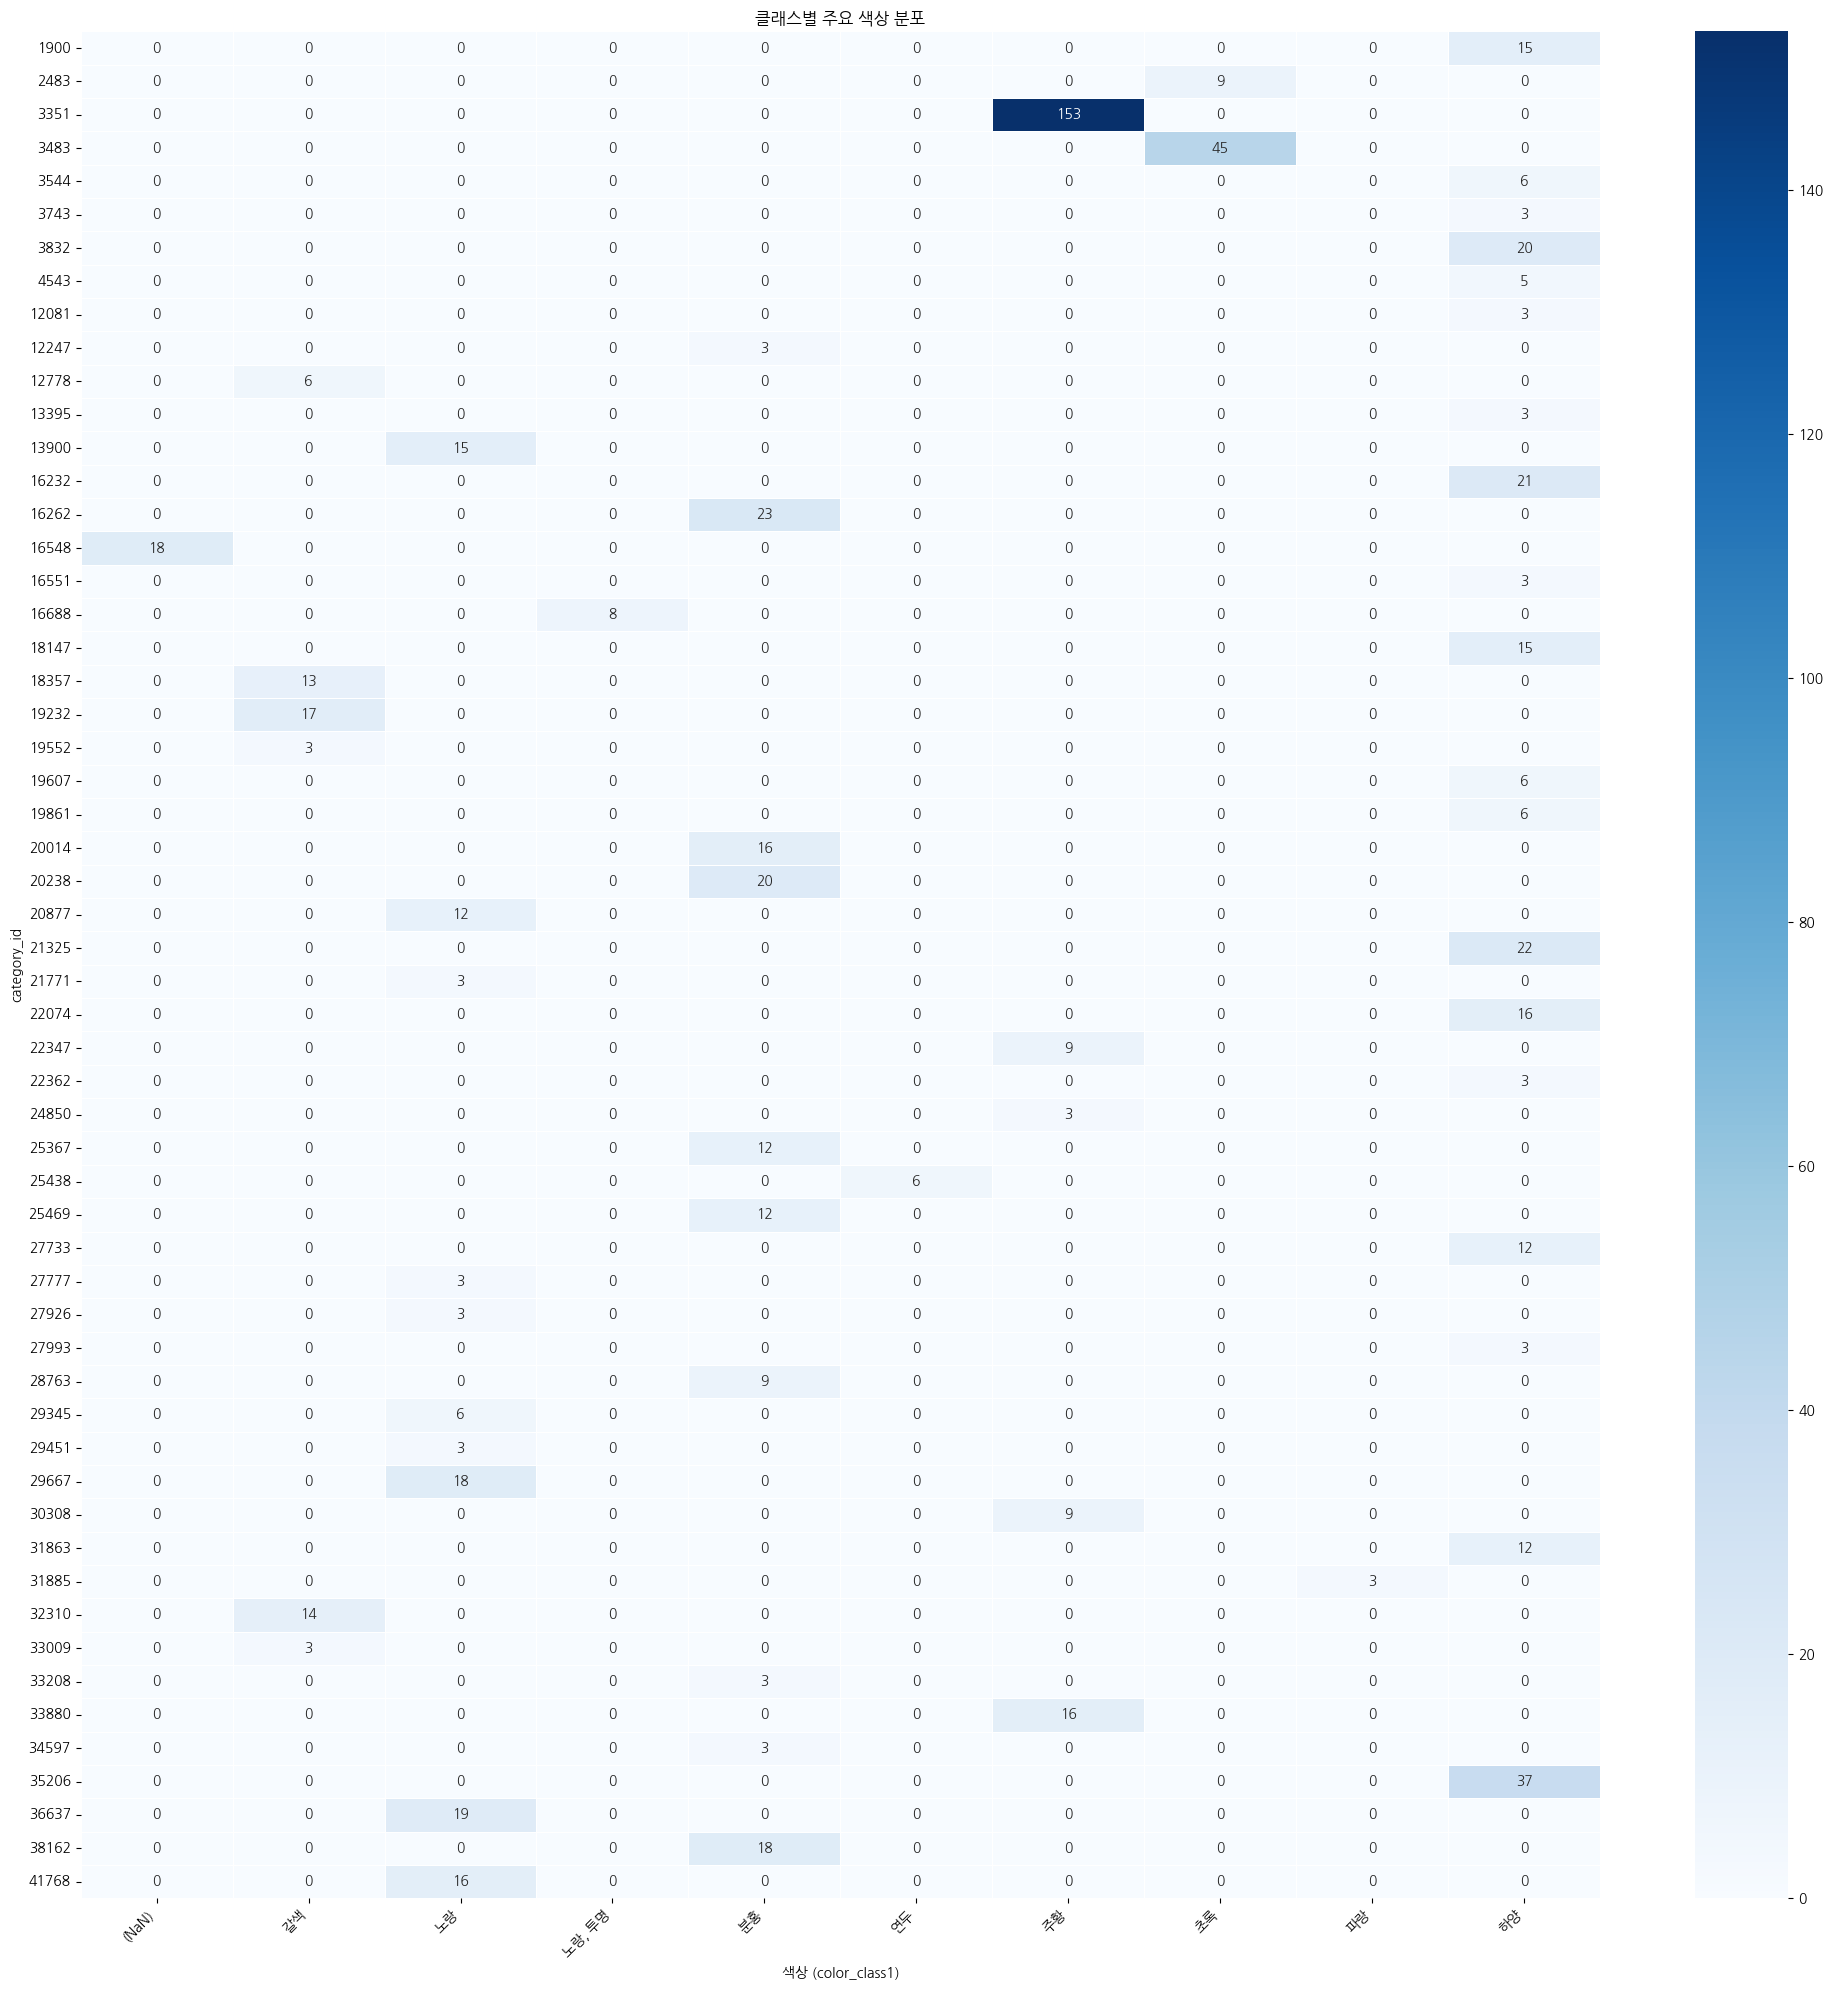

In [12]:
# =========================================
# 2-6. category_id vs Color Heatmap (수정본)
# =========================================
temp_df = obj_df.copy()
temp_df["color_class1"] = (
    temp_df["color_class1"]
    .fillna("(NaN)")
    .astype(str)
    .str.strip()
    .replace("", "(없음)")
)

if "category_id" in temp_df.columns and "color_class1" in temp_df.columns:

    ct = pd.crosstab(temp_df["category_id"], temp_df["color_class1"])

    plt.figure(figsize=(20, 20))

    ax = sns.heatmap(
        ct,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=0.5,
        linecolor="white",
        cbar=True,
        annot_kws={"size": 10}
    )

    ax.set_title("클래스별 주요 색상 분포")
    ax.set_xlabel("색상 (color_class1)")
    ax.set_ylabel("category_id")

    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

In [13]:
# =========================================
# 1. category_id별 color_class1 개수 확인
# =========================================
color_conflict = (
    obj_df.groupby("category_id")["color_class1"]
    .nunique()
    .reset_index(name="num_colors")
)

# color가 2개 이상인 클래스만
color_conflict = color_conflict[color_conflict["num_colors"] >= 2].copy()

# 어떤 색들이 있는지도 같이 보기
color_summary = (
    obj_df.groupby("category_id")["color_class1"]
    .apply(lambda x: sorted([v for v in x.dropna().unique().tolist()]))
    .reset_index(name="color_list")
)

color_conflict = color_conflict.merge(color_summary, on="category_id", how="left")
color_conflict = color_conflict.sort_values(["num_colors", "category_id"], ascending=[False, True]).reset_index(drop=True)

print("color 다른 클래스 수:", len(color_conflict))
display(color_conflict)

color 다른 클래스 수: 0


,category_id,num_colors,color_list


## 2-7. 클래스 vs 모양 heatmap

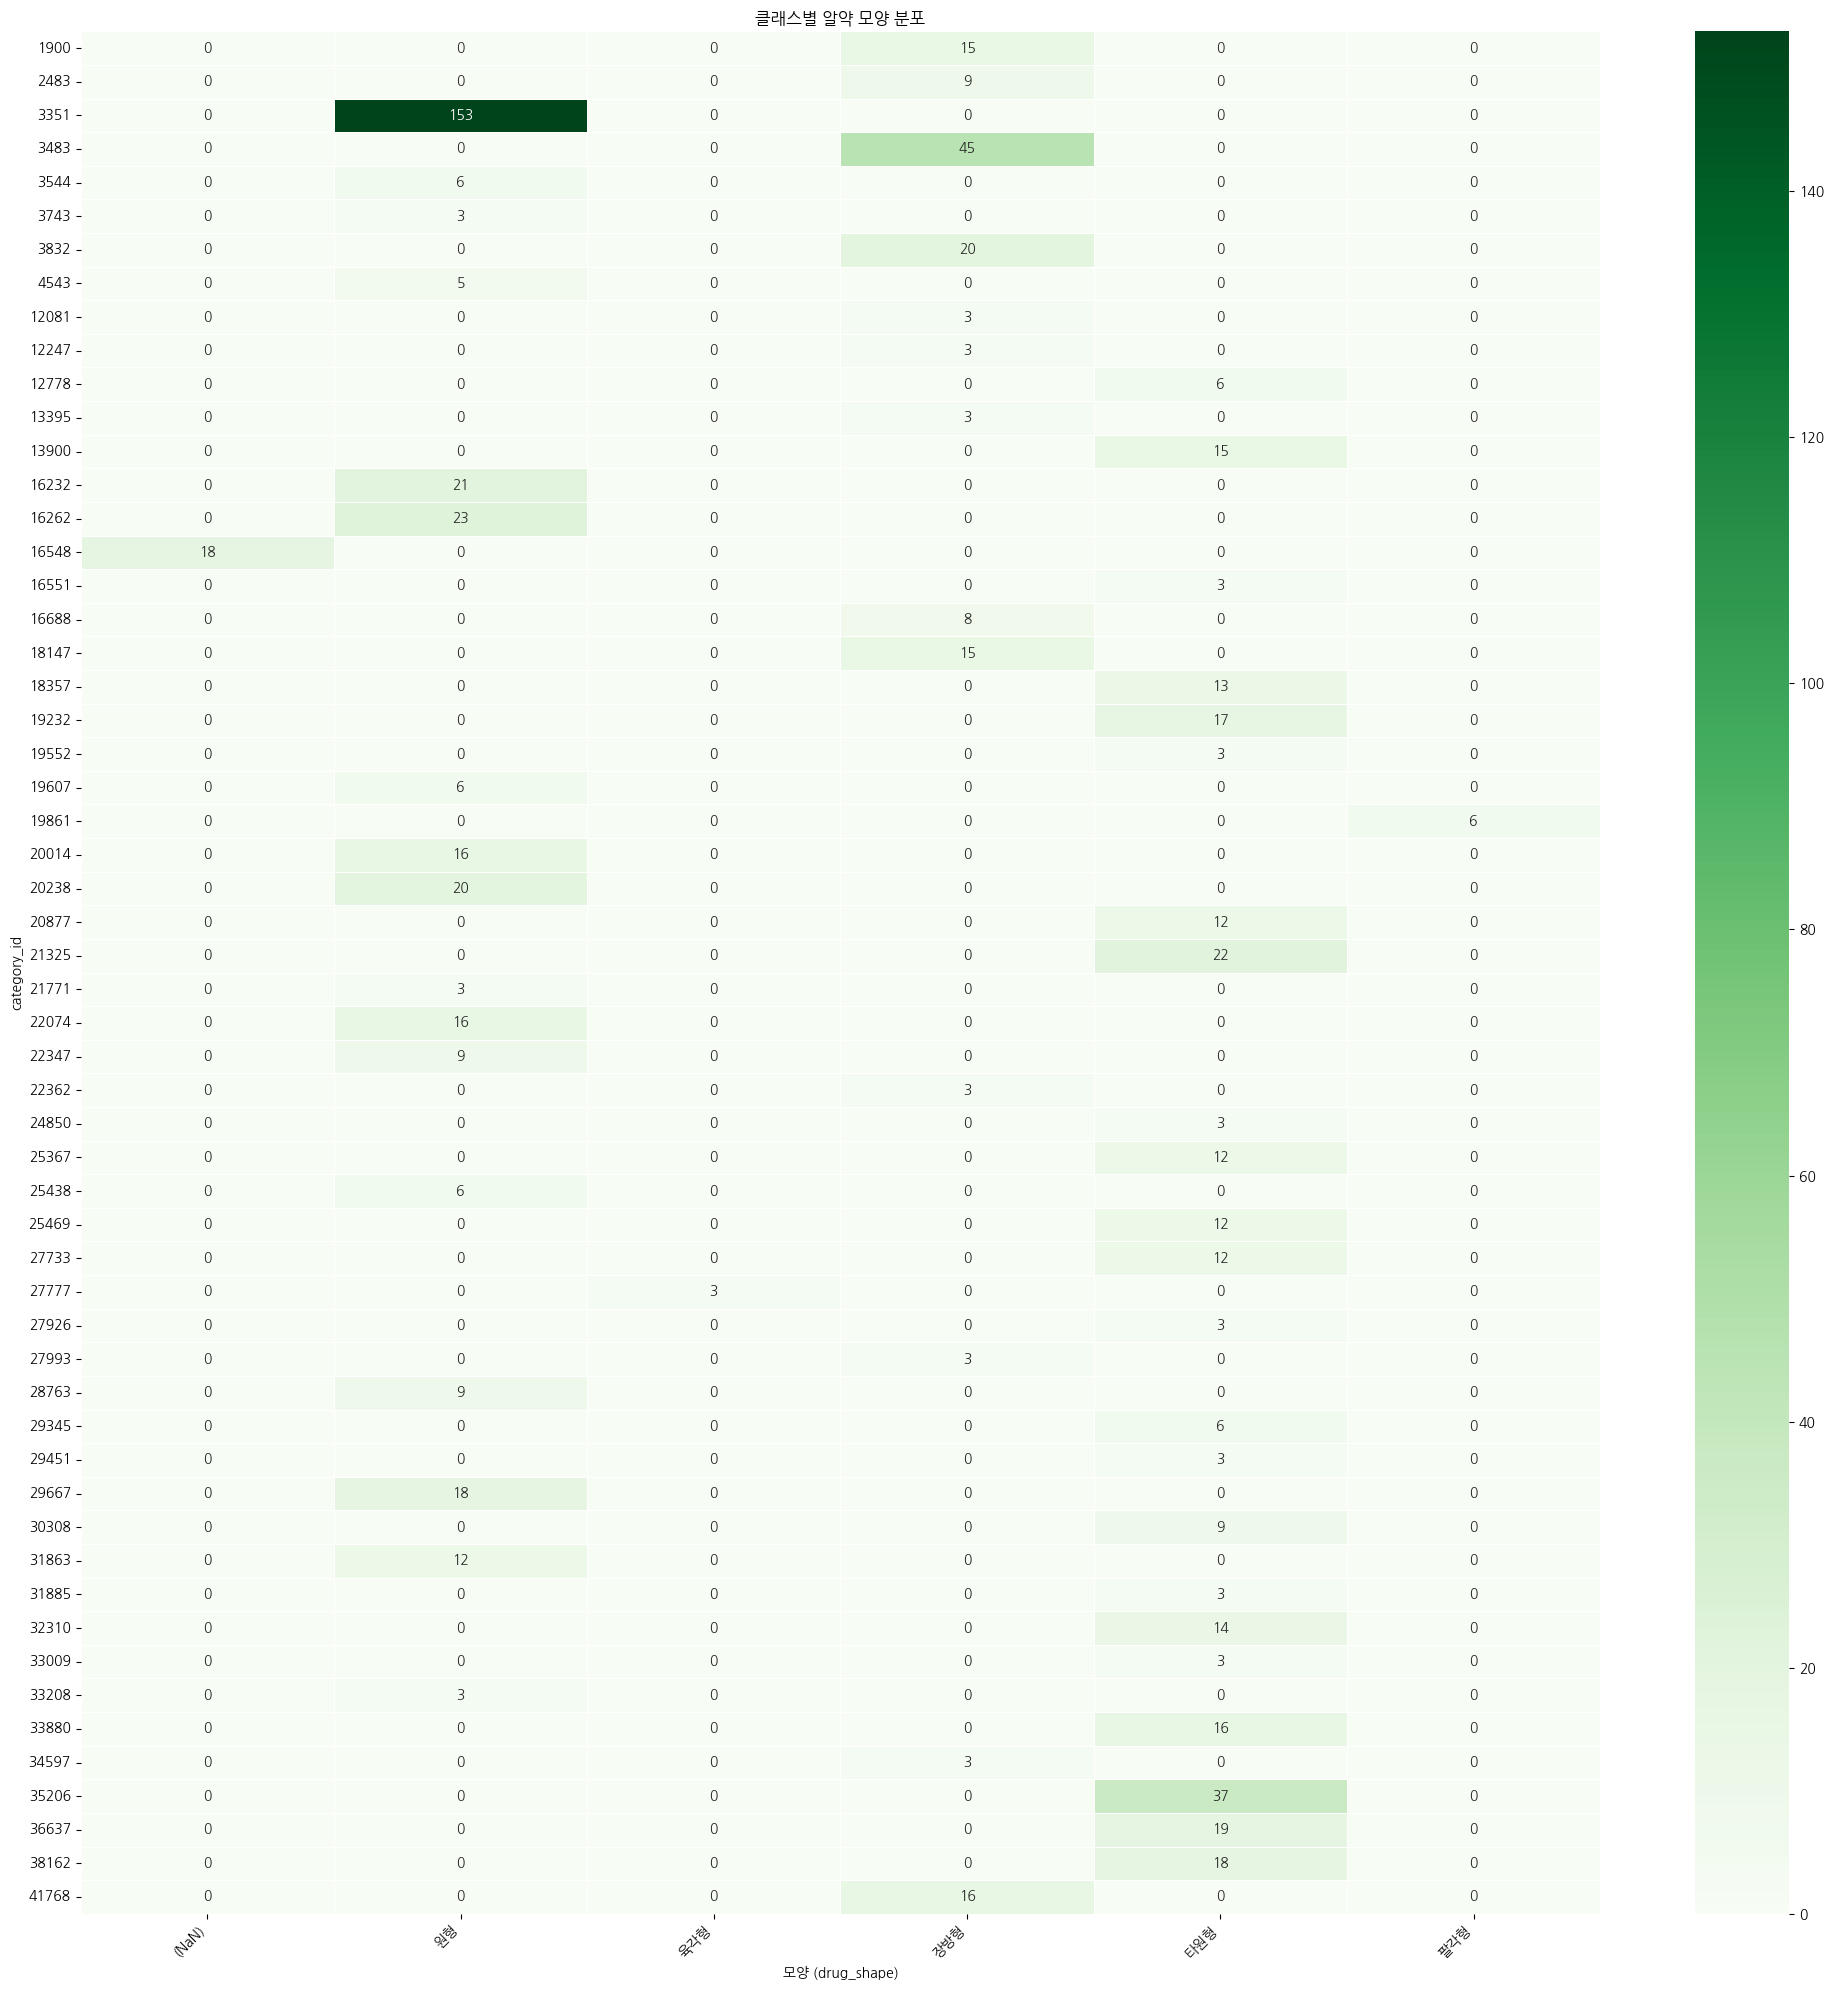

In [14]:
# =========================================
# 2-7. category_id vs Shape Heatmap (수정본)
# =========================================
temp_df = obj_df.copy()
temp_df["drug_shape"] = (
    temp_df["drug_shape"]
    .fillna("(NaN)")
    .astype(str)
    .str.strip()
    .replace("", "(없음)")
)

if "category_id" in temp_df.columns and "drug_shape" in temp_df.columns:
    
    ct = pd.crosstab(temp_df["category_id"], temp_df["drug_shape"])

    plt.figure(figsize=(20, 20))

    ax = sns.heatmap(
        ct,
        annot=True,
        fmt="d",
        cmap="Greens",
        linewidths=0.5,
        linecolor="white",
        cbar=True,
        annot_kws={"size": 10}
    )

    ax.set_title("클래스별 알약 모양 분포")
    ax.set_xlabel("모양 (drug_shape)")
    ax.set_ylabel("category_id")

    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

In [15]:
# =========================================
# 1. category_id별 shape 개수 확인
# =========================================
shape_conflict = (
    obj_df.groupby("category_id")["drug_shape"]
    .nunique()
    .reset_index(name="num_shapes")
)

# shape 2개 이상인 클래스만
shape_conflict = shape_conflict[shape_conflict["num_shapes"] >= 2]

print("shape 다른 클래스 수:", len(shape_conflict))
display(shape_conflict)

shape 다른 클래스 수: 0


,category_id,num_shapes


## 2-9. 색상 × 모양 별 클래스 분포

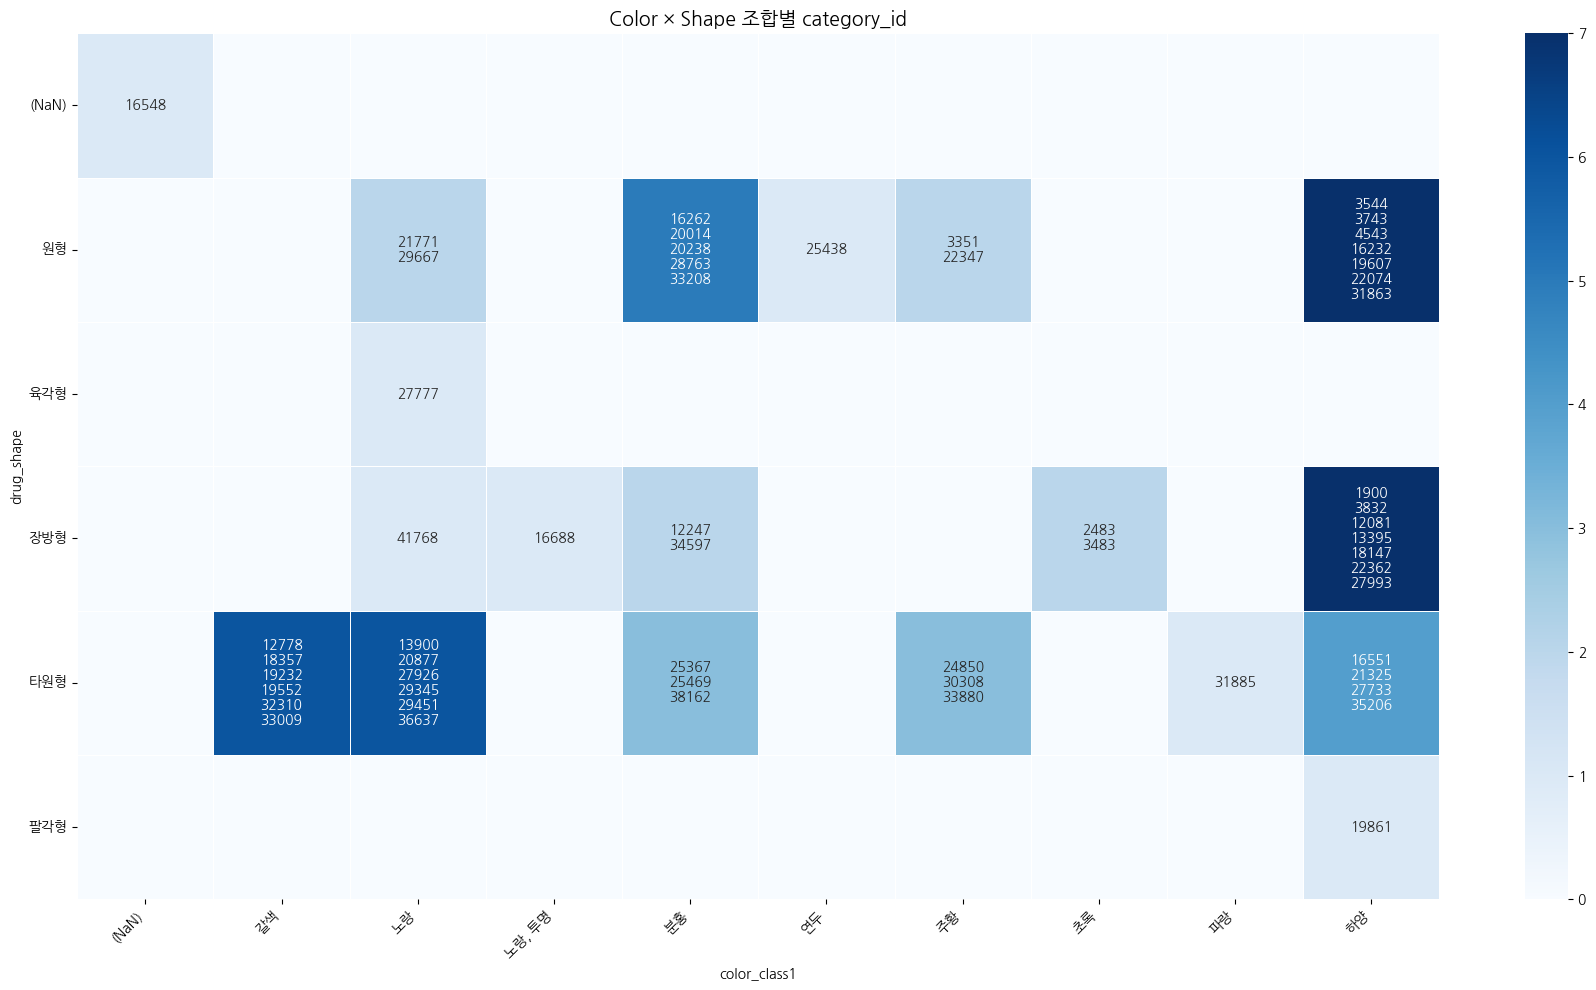

In [16]:
# =========================================
# 2-9. x축: color, y축: shape, 셀: category_id 줄 단위 표시
# =========================================

temp_df = obj_df.copy()

temp_df["color_class1"] = (
    temp_df["color_class1"]
    .fillna("(NaN)")
    .astype(str)
    .str.strip()
    .replace("", "(없음)")
)

temp_df["drug_shape"] = (
    temp_df["drug_shape"]
    .fillna("(NaN)")
    .astype(str)
    .str.strip()
    .replace("", "(없음)")
)

# -----------------------------------------
# 줄 단위로 category_id 생성
# -----------------------------------------
combo_df = (
    temp_df.groupby(["drug_shape", "color_class1"])["category_id"]
    .apply(lambda x: "\n".join(map(str, sorted(x.unique().tolist()))))
    .reset_index(name="category_ids")
)

# 개수
count_df = (
    temp_df.groupby(["drug_shape", "color_class1"])["category_id"]
    .nunique()
    .reset_index(name="num_classes")
)

combo_df = combo_df.merge(
    count_df,
    on=["drug_shape", "color_class1"],
    how="left"
)

# pivot
pivot_text = combo_df.pivot(
    index="drug_shape",
    columns="color_class1",
    values="category_ids"
).fillna("")

pivot_num = combo_df.pivot(
    index="drug_shape",
    columns="color_class1",
    values="num_classes"
).fillna(0)

# -----------------------------------------
# 시각화
# -----------------------------------------
plt.figure(figsize=(18, 10))

ax = sns.heatmap(
    pivot_num,
    annot=pivot_text,
    fmt="",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    annot_kws={
        "size": 10,
        "ha": "center",
        "va": "center"
    }
)

ax.set_title("Color × Shape 조합별 category_id", fontsize=14)
ax.set_xlabel("color_class1")
ax.set_ylabel("drug_shape")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 2-9. 클래스 vs 앞면 문자 heatmap

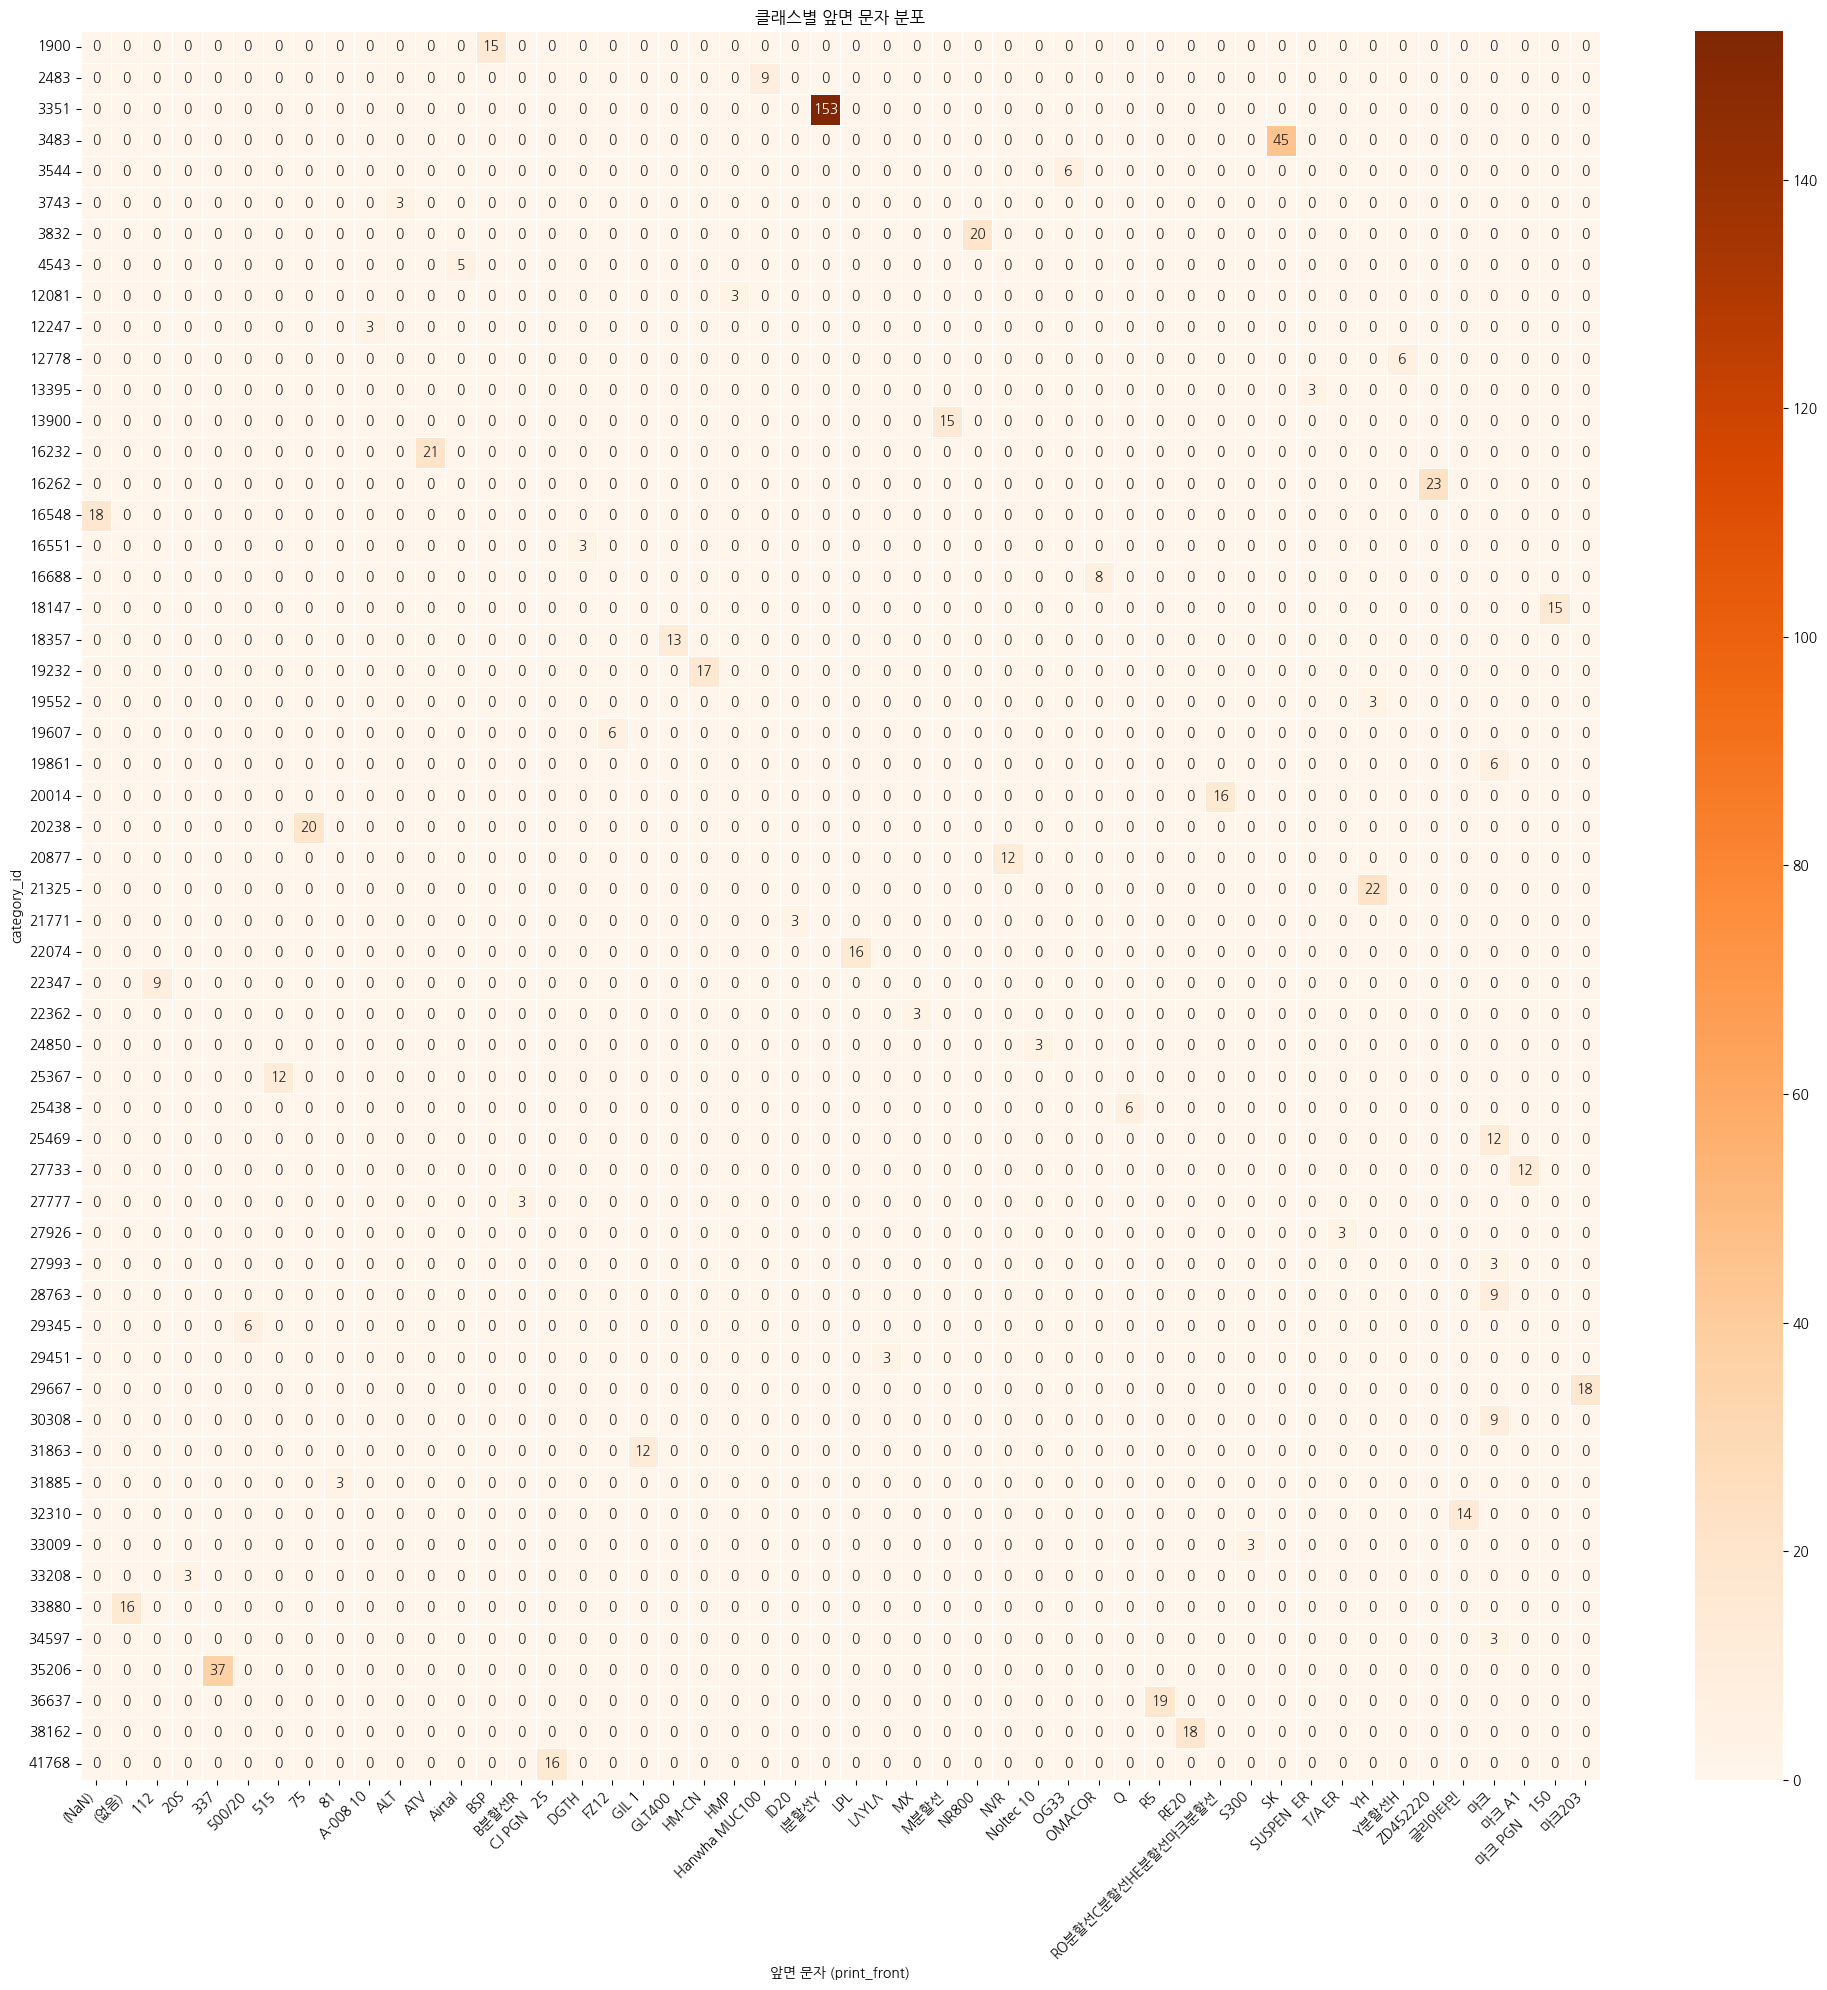

In [17]:
# =========================================
# 2-9. category_id vs Print Front Heatmap (수정본)
# =========================================
temp_df = obj_df.copy()
temp_df["print_front"] = (
    temp_df["print_front"]
    .fillna("(NaN)")
    .astype(str)
    .str.strip()
    .replace("", "(없음)")
)

if "category_id" in temp_df.columns and "print_front" in temp_df.columns:
    
    ct = pd.crosstab(temp_df["category_id"], temp_df["print_front"])

    plt.figure(figsize=(20, 20))

    ax = sns.heatmap(
        ct,
        annot=True,
        fmt="d",
        cmap="Oranges",
        linewidths=0.5,
        linecolor="white",
        cbar=True,
        annot_kws={"size": 10}
    )

    ax.set_title("클래스별 앞면 문자 분포")
    ax.set_xlabel("앞면 문자 (print_front)")
    ax.set_ylabel("category_id")

    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

In [18]:
# =========================================
# 1. category_id별 print_front 개수 확인
# =========================================
temp_df = obj_df.copy()
temp_df["print_front"] = temp_df["print_front"].replace("", "(없음)")

print_conflict = (
    temp_df.groupby("category_id")["print_front"]
    .nunique()
    .reset_index(name="num_prints")
)

# print가 2개 이상인 클래스만
print_conflict = print_conflict[print_conflict["num_prints"] >= 2].copy()

# 어떤 print들이 있는지도 같이 보기
print_summary = (
    temp_df.groupby("category_id")["print_front"]
    .apply(lambda x: sorted([v for v in x.dropna().unique().tolist()]))
    .reset_index(name="print_list")
)

print_conflict = print_conflict.merge(print_summary, on="category_id", how="left")
print_conflict = print_conflict.sort_values(["num_prints", "category_id"], ascending=[False, True]).reset_index(drop=True)

print("print 다른 클래스 수:", len(print_conflict))
display(print_conflict)

print 다른 클래스 수: 0


,category_id,num_prints,print_list


## 2-10. 수치형 메타데이터 분포

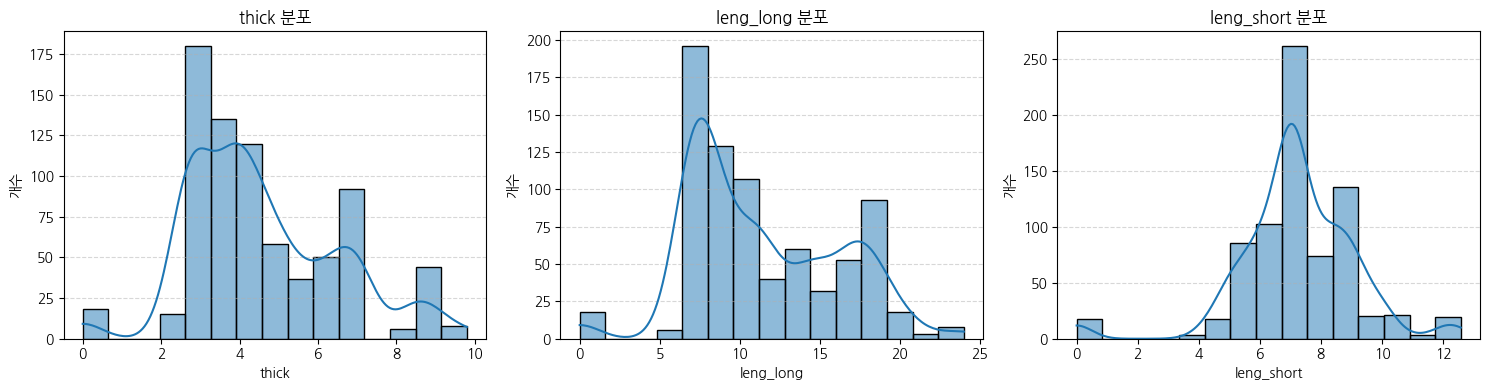

In [19]:
# =========================================
# 2-10. Numeric Metadata Distribution (object-level)
# =========================================
num_cols = ["thick", "leng_long", "leng_short"]
num_cols = [c for c in num_cols if c in obj_df.columns]

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))

if len(num_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    sns.histplot(
        data=obj_df,
        x=col,
        bins=15,
        kde=True,
        ax=ax
    )

    ax.set_title(f"{col} 분포")
    ax.set_xlabel(col)
    ax.set_ylabel("개수")

    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 2-11. 클래스별 수치형 메타데이터 boxplot

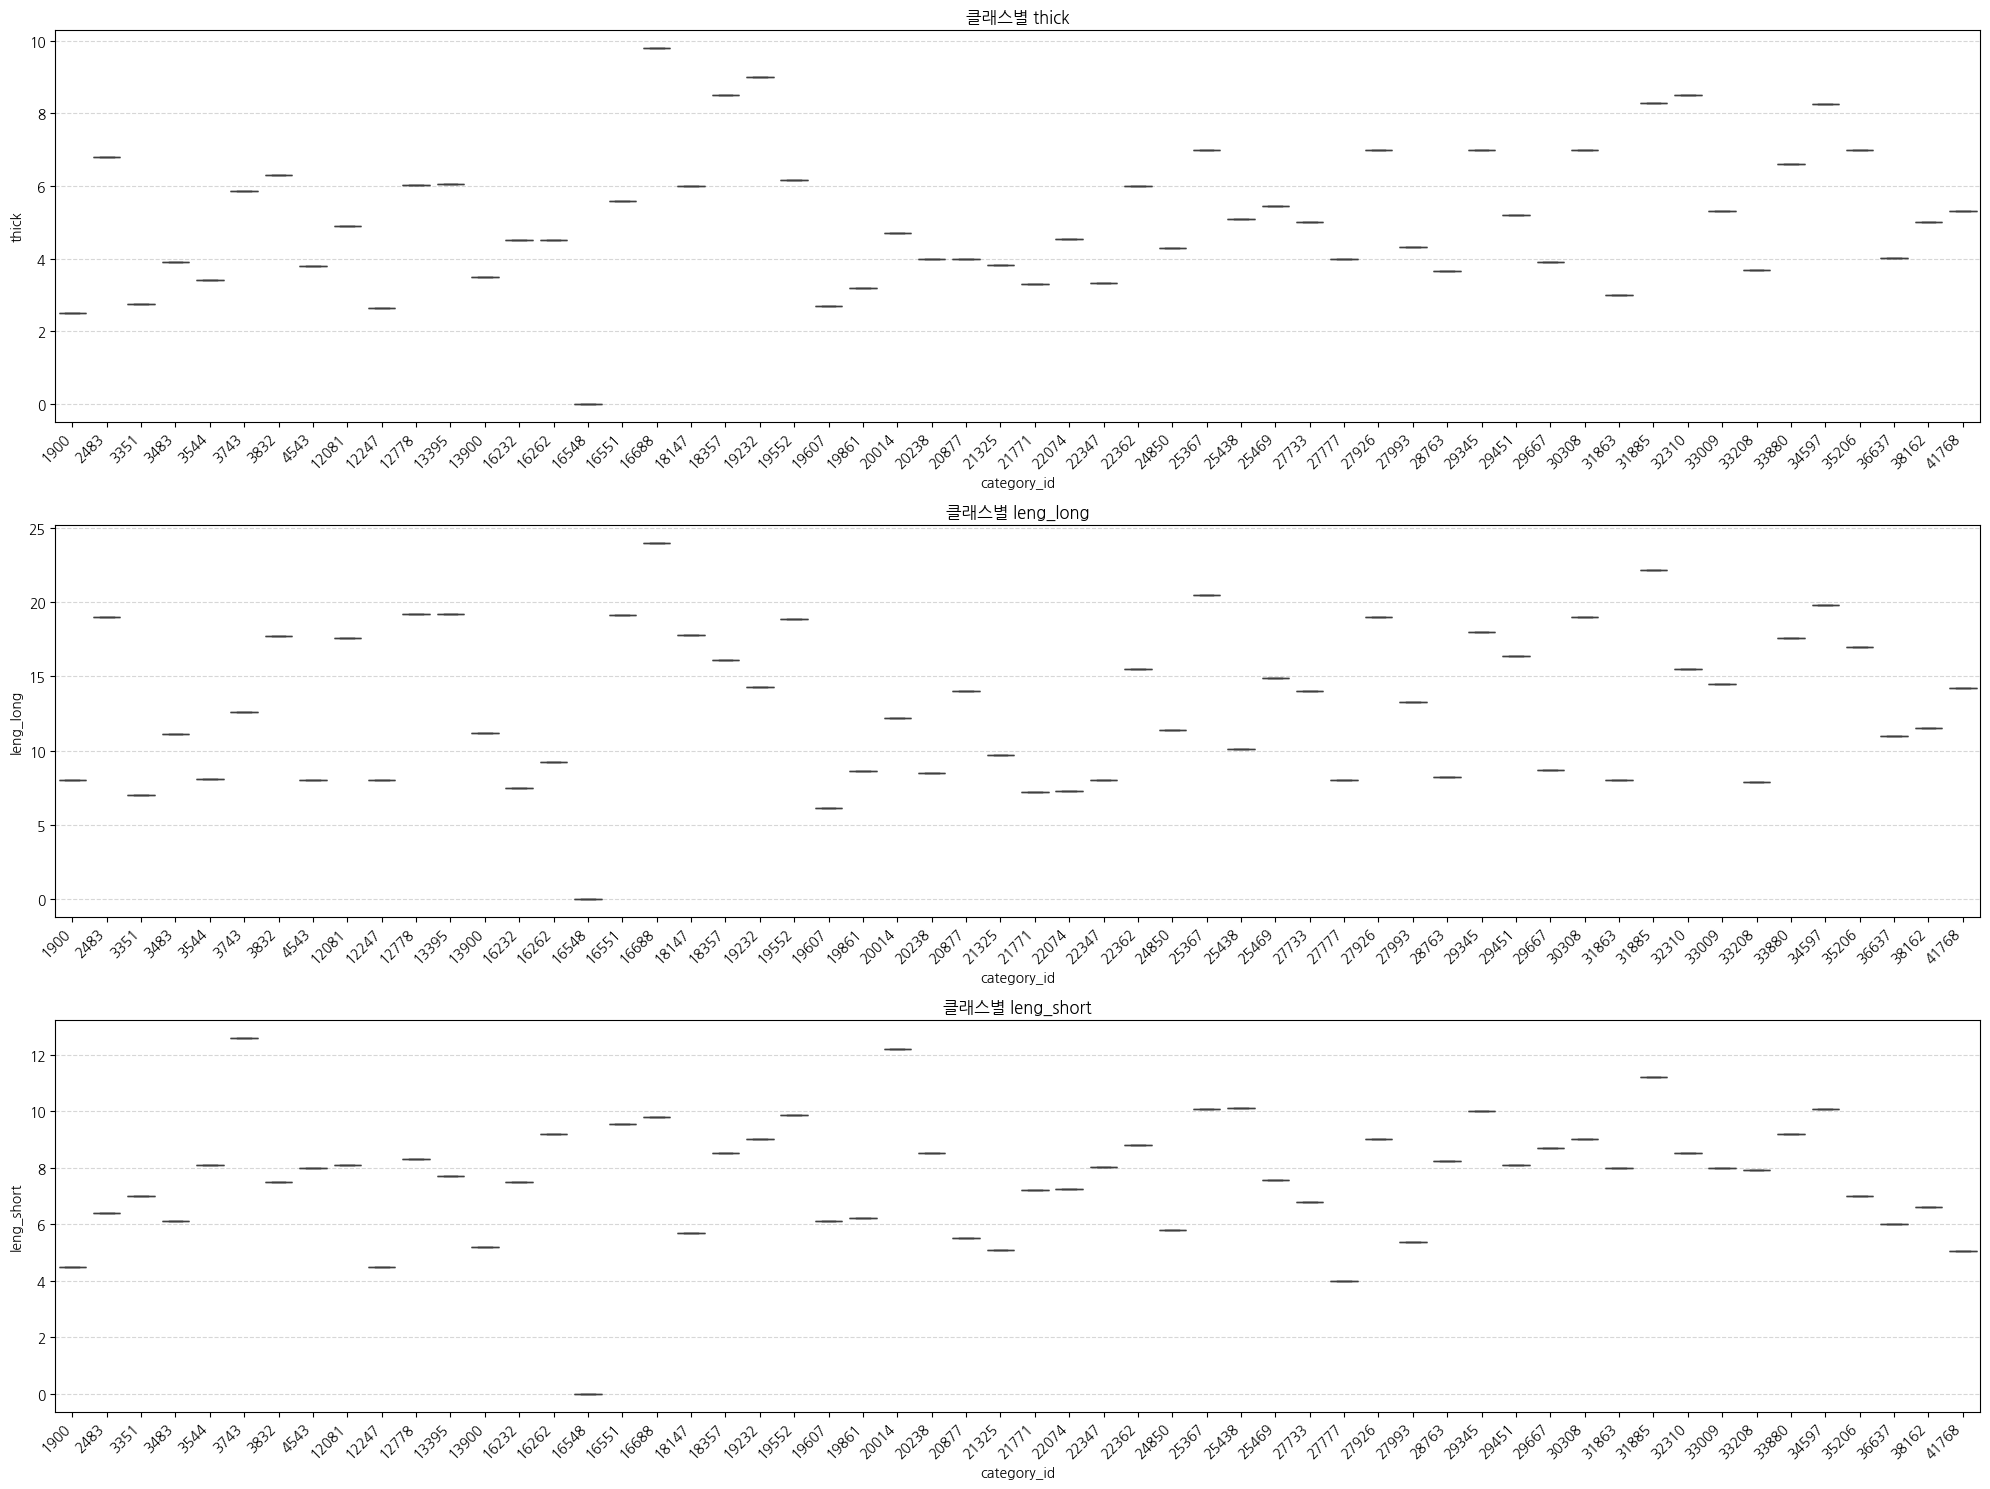

In [20]:
# =========================================
# 2-11. Numeric Metadata by category_id
# =========================================
num_cols = ["thick", "leng_long", "leng_short"]
num_cols = [c for c in num_cols if c in obj_df.columns]

fig, axes = plt.subplots(len(num_cols), 1, figsize=(20, 5 * len(num_cols)))

if len(num_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=obj_df, x="category_id", y=col, ax=ax)

    ax.set_title(f"클래스별 {col}")
    ax.set_xlabel("category_id")
    ax.set_ylabel(col)

    plt.sca(ax)
    plt.xticks(rotation=45, ha="right")

    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 2-12. bbox 크기 분포

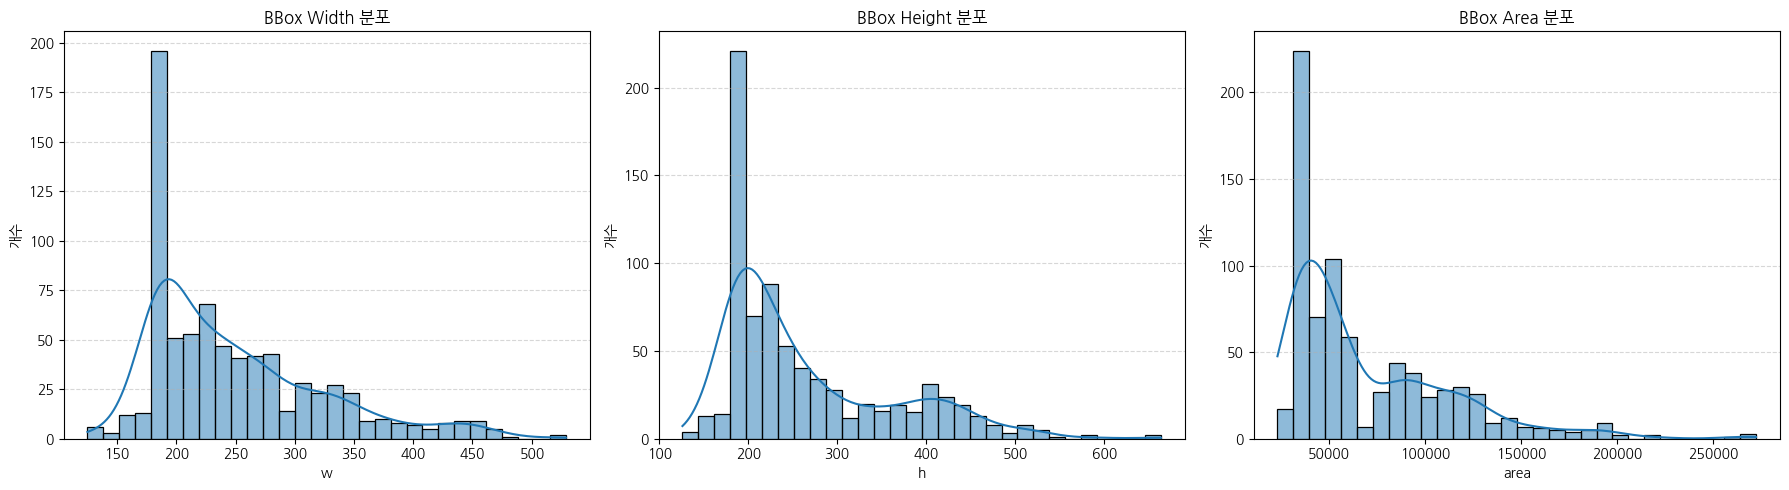

In [21]:
# =========================================
# 2-12. BBox Size Distribution
# =========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=obj_df, x="w", bins=30, kde=True, ax=axes[0])
axes[0].set_title("BBox Width 분포")
axes[0].set_xlabel("w")
axes[0].set_ylabel("개수")

sns.histplot(data=obj_df, x="h", bins=30, kde=True, ax=axes[1])
axes[1].set_title("BBox Height 분포")
axes[1].set_xlabel("h")
axes[1].set_ylabel("개수")

sns.histplot(data=obj_df, x="area", bins=30, kde=True, ax=axes[2])
axes[2].set_title("BBox Area 분포")
axes[2].set_xlabel("area")
axes[2].set_ylabel("개수")

for ax in axes:
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

---

# 3. Test 이미지 EDA

## 3-1. 이미지 크기 분포

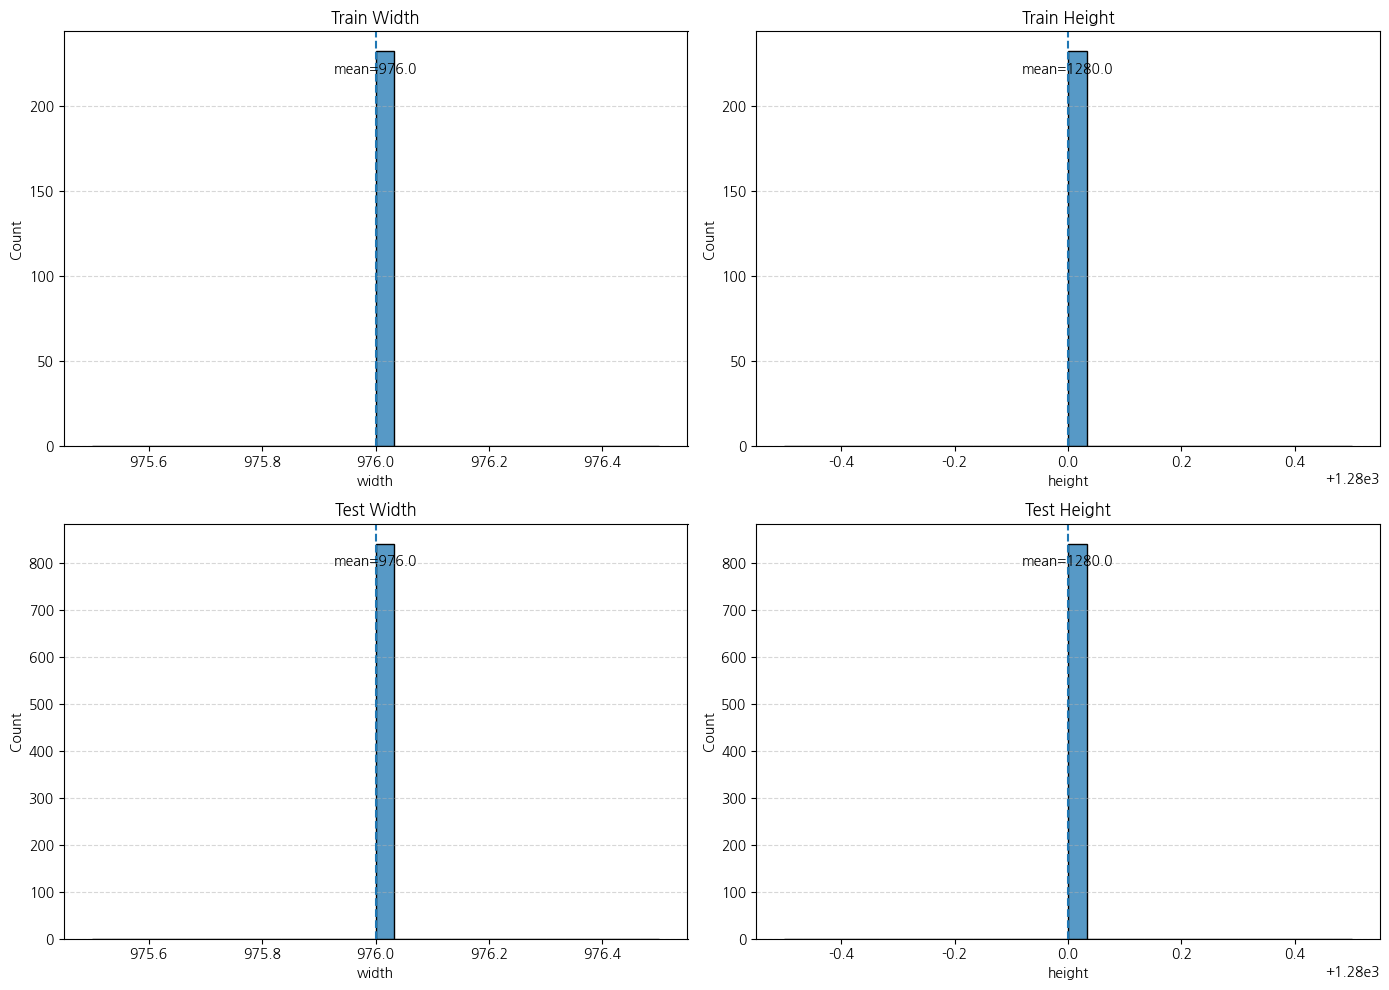

In [22]:
# =========================================
# 3-1. Train vs Test Image Size Distribution
# =========================================
# --- Train ---
train_sizes = []
for p in train_img_paths:
    img = cv2.imread(str(p))
    if img is not None:
        h, w = img.shape[:2]
        train_sizes.append((w, h))

train_size_df = pd.DataFrame(train_sizes, columns=["width", "height"])


# --- Test ---
test_sizes = []
for p in test_img_paths:
    img = cv2.imread(str(p))
    if img is not None:
        h, w = img.shape[:2]
        test_sizes.append((w, h))

test_size_df = pd.DataFrame(test_sizes, columns=["width", "height"])


# =========================================
# 시각화 (4개 subplot)
# =========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Train Width
sns.histplot(train_size_df["width"], bins=30, ax=axes[0, 0])
axes[0, 0].set_title("Train Width")

# 라벨 (mean)
mean_val = train_size_df["width"].mean()
axes[0, 0].axvline(mean_val, linestyle="--")
axes[0, 0].text(mean_val, axes[0, 0].get_ylim()[1]*0.9, f"mean={mean_val:.1f}", ha="center")


# 2. Train Height
sns.histplot(train_size_df["height"], bins=30, ax=axes[0, 1])
axes[0, 1].set_title("Train Height")

mean_val = train_size_df["height"].mean()
axes[0, 1].axvline(mean_val, linestyle="--")
axes[0, 1].text(mean_val, axes[0, 1].get_ylim()[1]*0.9, f"mean={mean_val:.1f}", ha="center")


# 3. Test Width
sns.histplot(test_size_df["width"], bins=30, ax=axes[1, 0])
axes[1, 0].set_title("Test Width")

mean_val = test_size_df["width"].mean()
axes[1, 0].axvline(mean_val, linestyle="--")
axes[1, 0].text(mean_val, axes[1, 0].get_ylim()[1]*0.9, f"mean={mean_val:.1f}", ha="center")


# 4. Test Height
sns.histplot(test_size_df["height"], bins=30, ax=axes[1, 1])
axes[1, 1].set_title("Test Height")

mean_val = test_size_df["height"].mean()
axes[1, 1].axvline(mean_val, linestyle="--")
axes[1, 1].text(mean_val, axes[1, 1].get_ylim()[1]*0.9, f"mean={mean_val:.1f}", ha="center")


# 공통 스타일
for ax in axes.flatten():
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 3-2. 샘플 이미지 확인

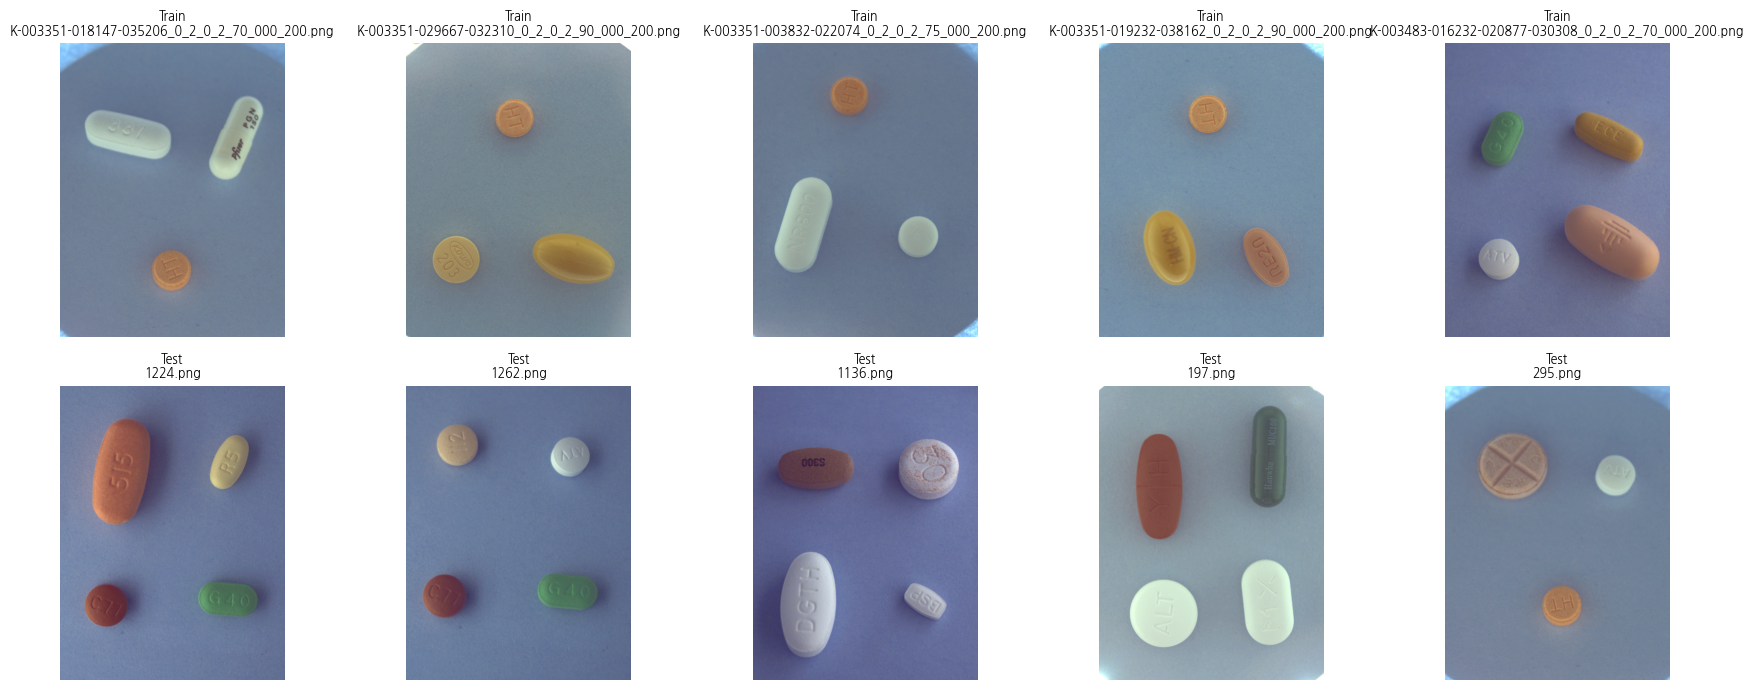

In [23]:
# =========================================
# Train vs Test Sample Visualization (5 + 5)
# =========================================
import random

# 샘플 선택
train_samples = random.sample(train_img_paths, 5)
test_samples = random.sample(test_img_paths, 5)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

# -----------------------------
# Train (위)
# -----------------------------
for i, p in enumerate(train_samples):
    img = cv2.imread(str(p))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Train\n{p.name}", fontsize=9)
    axes[0, i].axis("off")

# -----------------------------
# Test (아래)
# -----------------------------
for i, p in enumerate(test_samples):
    img = cv2.imread(str(p))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Test\n{p.name}", fontsize=9)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## 3-3. 밝기 분포

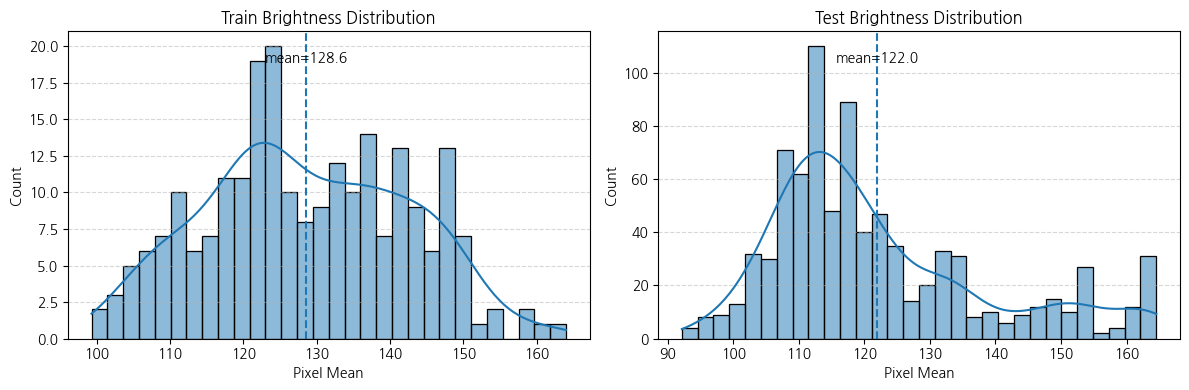

In [24]:
# =========================================
# Train vs Test Brightness Distribution
# =========================================
train_brightness = []
for p in train_img_paths:
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        train_brightness.append(img.mean())

test_brightness = []
for p in test_img_paths:
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        test_brightness.append(img.mean())

train_brightness = pd.Series(train_brightness, name="brightness")
test_brightness = pd.Series(test_brightness, name="brightness")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train
sns.histplot(train_brightness, bins=30, kde=True, ax=axes[0])
axes[0].set_title("Train Brightness Distribution")
axes[0].set_xlabel("Pixel Mean")
axes[0].set_ylabel("Count")

train_mean = train_brightness.mean()
axes[0].axvline(train_mean, linestyle="--")
axes[0].text(train_mean, axes[0].get_ylim()[1] * 0.9, f"mean={train_mean:.1f}", ha="center")

# Test
sns.histplot(test_brightness, bins=30, kde=True, ax=axes[1])
axes[1].set_title("Test Brightness Distribution")
axes[1].set_xlabel("Pixel Mean")
axes[1].set_ylabel("Count")

test_mean = test_brightness.mean()
axes[1].axvline(test_mean, linestyle="--")
axes[1].text(test_mean, axes[1].get_ylim()[1] * 0.9, f"mean={test_mean:.1f}", ha="center")

for ax in axes:
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 3-4. Blur / 선명도

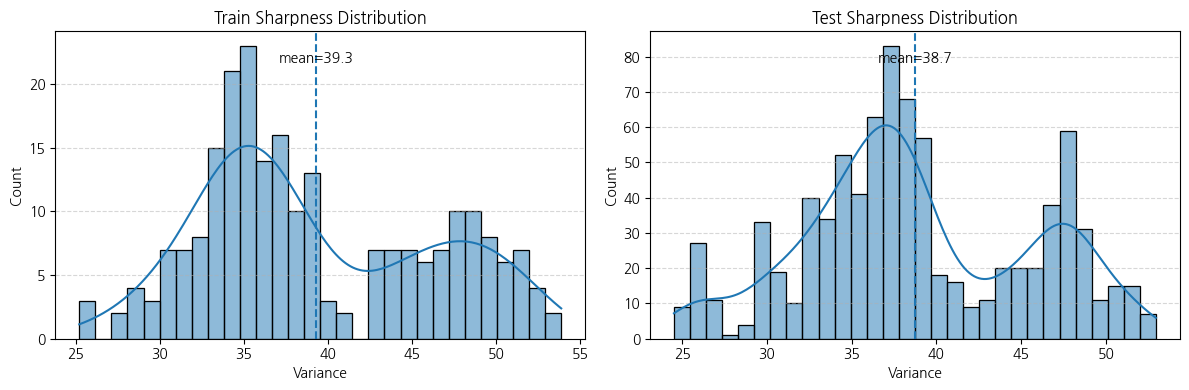

In [25]:
# =========================================
# Train vs Test Sharpness (Laplacian)
# =========================================

# --- Train ---
train_sharpness = []
for p in train_img_paths:
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        val = cv2.Laplacian(img, cv2.CV_64F).var()
        train_sharpness.append(val)

# --- Test ---
test_sharpness = []
for p in test_img_paths:
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        val = cv2.Laplacian(img, cv2.CV_64F).var()
        test_sharpness.append(val)

train_sharpness = pd.Series(train_sharpness, name="sharpness")
test_sharpness = pd.Series(test_sharpness, name="sharpness")

# --- 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train
sns.histplot(train_sharpness, bins=30, kde=True, ax=axes[0])
axes[0].set_title("Train Sharpness Distribution")
axes[0].set_xlabel("Variance")
axes[0].set_ylabel("Count")

train_mean = train_sharpness.mean()
axes[0].axvline(train_mean, linestyle="--")
axes[0].text(train_mean, axes[0].get_ylim()[1]*0.9, f"mean={train_mean:.1f}", ha="center")

# Test
sns.histplot(test_sharpness, bins=30, kde=True, ax=axes[1])
axes[1].set_title("Test Sharpness Distribution")
axes[1].set_xlabel("Variance")
axes[1].set_ylabel("Count")

test_mean = test_sharpness.mean()
axes[1].axvline(test_mean, linestyle="--")
axes[1].text(test_mean, axes[1].get_ylim()[1]*0.9, f"mean={test_mean:.1f}", ha="center")

# 공통 스타일
for ax in axes:
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()